In [16]:
import os
import sys
import glob
import h5py
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt
from IPython.display import display, HTML

from vip_slap2_analysis.voltage.extraction import load_voltage_roi_transform_h5
from vip_slap2_analysis.plotting.plot_session_heatmap import _robust_row_zscore
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.voltage.summary import VoltageSummary
from vip_slap2_analysis.voltage.postprocess import concat_rois_across_trials
from vip_slap2_analysis.utils.utils import save_figure

from scipy import signal as scipy_signal

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

display(HTML("<style>.container { width:100% !important; }</style>"))
warnings.filterwarnings("default")


In [3]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

In [4]:
today_str = datetime.today().strftime('%Y-%m-%d')

BASE_PATH = Path(r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics')
SAVE_PATH = Path(r'C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures')

TARGET_MICE = [
    826031,
    826032
]

PARADIGMS = ["change_detection_passive"]
EXCLUDE_SESSION_TYPES = ["expression_check", "volume_imaging"]

# Voltage extraction writes files like:
#   voltage_session_traces_dff_robust_f0_trial.h5
# This variant controls the filename suffix. The plotted dataset is SIGNAL below.
TRACE_VARIANT = "dff_robust_f0_trial"
SIGNAL = "dff"      # one of: "raw_f", "f0", "dff"

# Optional direct override. Leave as None to resolve from asset.derived_dir / "voltage".
SESSION_TRACE_H5 = None

In [5]:
registry = VIPSessionRegistry.from_basepath(BASE_PATH)

process_df = registry.sessions(
    subject_ids=TARGET_MICE,
    exclude_session_types=EXCLUDE_SESSION_TYPES,
    paradigms=PARADIGMS,
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Found {len(assets)} candidate sessions.")
display(process_df)

Found 19 candidate sessions.


,session_id,subject_id,session_#,session_date,indicator1,indicator2,dmd1_depth,dmd2_depth,paradigm,session_type,...,instrument_id,camera_type,has raster ROI?,has integration roi?,behavior_rig,quality,flags,session_dir,purpose,notes
0,826031_2026-01-30_15-04-02,826031,2,2026-01-30,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
1,826031_2026-02-01_11-01-50,826031,3,2026-02-01,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
2,826031_2026-02-02_10-23-53,826031,4,2026-02-02,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
3,826031_2026-02-03_14-21-45,826031,5,2026-02-03,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
4,826031_2026-02-04_12-15-34,826031,6,2026-02-04,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
5,826031_2026-02-05_09-28-56,826031,7,2026-02-05,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
6,826031_2026-02-06_10-21-20,826031,8,2026-02-06,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
7,826031_2026-02-10_10-48-51,826031,9,2026-02-10,ASAP7y,NaN,50,250,change_detection_passive,novel,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
8,826031_2026-02-11_12-42-21,826031,10,2026-02-11,ASAP7y,NaN,50,250,change_detection_passive,novel+,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
9,826031_2026-02-12_07-43-37,826031,11,2026-02-12,ASAP7y,NaN,50,250,change_detection_passive,novel+,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN


# Shared-signal correlation analysis

This notebook is a first-pass analysis for the lab-meeting slide on shared ASAP7y signal structure. It asks three deliberately modest questions:

1. **How correlated are dendritic ROI signals within and between DMDs?**
2. **How does apparent sharedness depend on the analysis timescale?**
3. **Which pairs/sessions are worth following up with frequency-specific, residualization, and morphology-based analyses?**

Interpretation guardrail: raw pairwise correlations are a useful map of shared structure, but they are not by themselves evidence that two ROIs are from the same neuron. Slow drift, image flashes, running/arousal, motion, optical/electrical common mode, and F0 estimation can all inflate shared correlations. The best same-cell candidates should be high-correlation **after** frequency restriction, time-shift controls, residualization, and morphological review.

In [81]:
# Analysis configuration.
# For the slide concept: use one short example window for the matrices, and a sweep
# across several window lengths for the pooled summary plot.
DMD_COLORS = ['#e99c81','#7bbcd5','green']
SESSION_INDEX = 1              # representative session for the left-side matrices
EXAMPLE_START_SEC = None       # None = choose first clean window after the start pad
EXAMPLE_WINDOW_SEC = 180      # short-end matrix example
START_PAD_SEC = 10.0           # avoid initial transients when auto-choosing starts

# Downsample before correlation so pooled analyses remain fast. This is appropriate
# for the slide-level slow/mid-timescale correlation question. For same-cell inference
# using >50-100 Hz components, use a higher target_fs_hz and explicit high-pass analysis.
CORR_TARGET_FS_HZ = 250.0
VALID_ROIS_ONLY = True
ROBUST_CLIP_Z = 8.0            # reduce influence of rare artifacts; set None to disable

# Pooled window sweep.
WINDOW_LENGTHS_SEC = [5.0, 30.0, 180.0]
N_WINDOWS_PER_LENGTH = 6       # per session x window length; evenly spaced by default
MAX_SESSIONS = None            # set e.g. 2 for a smoke test
WINDOW_START_MODE = "even"     # "even" or "random"
RANDOM_SEED = 0

# What to show on the slide.
# MATRIX_METRIC="r2" is visually clean for shared magnitude; MATRIX_METRIC="r" retains sign.
MATRIX_METRIC = "r2"           # "r" or "r2"
SUMMARY_METRIC = "median_r2"   # "median_r", "median_abs_r", or "median_r2"

OUT_DIR = SAVE_PATH / "asap7_signal_correlations"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Output directory:", OUT_DIR)

Output directory: C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\asap7_signal_correlations


## Helper functions

The helpers below load only the requested time window from the derived session H5, infer whether each dataset is stored as `ROI × time` or `time × ROI`, optionally downsample, and return ROI-major arrays shaped `n_rois × n_time`.

In [78]:
def _maybe_get(obj, name, default=None):
    """Safely get attr or dict key from an asset-like object."""
    if hasattr(obj, name):
        return getattr(obj, name)
    if isinstance(obj, dict) and name in obj:
        return obj[name]
    return default


def resolve_voltage_h5(asset, trace_variant=TRACE_VARIANT, session_trace_h5=SESSION_TRACE_H5):
    """
    Resolve the derived session-long voltage trace H5.

    Expected derived filename:
        derived/voltage/voltage_session_traces_{TRACE_VARIANT}.h5

    Falls back to asset.get_modality_assets('voltage')['trace_h5'] only if the
    derived postprocessed file is unavailable. For this analysis, the preferred
    input is the derived session dFF H5.
    """
    if session_trace_h5 is not None:
        path = Path(session_trace_h5)
        if not path.exists():
            raise FileNotFoundError(path)
        return path

    derived_dir = _maybe_get(asset, "derived_dir", None)
    candidates = []
    if derived_dir is not None:
        derived_dir = Path(derived_dir)
        candidates.extend([
            derived_dir / "voltage" / f"voltage_session_traces_{trace_variant}.h5",
            derived_dir / f"voltage_session_traces_{trace_variant}.h5",
        ])

    # Fallback: raw extraction trace H5, not ideal for this notebook because it
    # may not contain the session dFF/F0 products.
    if hasattr(asset, "get_modality_assets"):
        voltage_assets = asset.get_modality_assets("voltage")
        if voltage_assets.get("trace_h5") is not None:
            candidates.append(Path(voltage_assets["trace_h5"]))
    elif isinstance(asset, dict):
        try:
            p = asset.get("modality_assets", {}).get("voltage", {}).get("trace_h5")
            if p is not None:
                candidates.append(Path(p))
        except Exception:
            pass

    for path in candidates:
        if path.exists():
            return path

    print("Tried:")
    for path in candidates:
        print("  ", path)
    raise FileNotFoundError("Could not resolve voltage session trace H5.")


def _get_dmd_keys(h5):
    return sorted([k for k in h5.keys() if k.upper().startswith("DMD")])


def _decode_roi_ids(x, n=None):
    if x is None:
        return np.asarray([str(i) for i in range(n or 0)], dtype=str)
    out = []
    for v in x:
        if isinstance(v, bytes):
            out.append(v.decode("utf-8"))
        else:
            out.append(str(v))
    return np.asarray(out, dtype=str)


def _infer_trace_layout(y_ds, t_ds):
    """Return layout, n_rois, n_time for H5 trace dataset."""
    n_time = len(t_ds)
    shape = tuple(y_ds.shape)
    if len(shape) != 2:
        raise ValueError(f"Expected 2D trace dataset; got shape {shape}")
    if shape[1] == n_time:
        return "roi_time", shape[0], shape[1]
    if shape[0] == n_time:
        return "time_roi", shape[1], shape[0]
    raise ValueError(f"Could not infer trace layout. Trace shape={shape}; time length={n_time}")


def _estimate_fs_from_timebase(t, n_check=200_000):
    t = np.asarray(t, dtype=float)
    if len(t) < 3:
        return np.nan
    if len(t) > n_check:
        idx = np.linspace(0, len(t) - 1, n_check).astype(int)
        t_use = t[idx]
    else:
        t_use = t
    dt = np.diff(t_use)
    dt = dt[np.isfinite(dt) & (dt > 0)]
    if len(dt) == 0:
        return np.nan
    return float(1.0 / np.nanmedian(dt))


def inspect_voltage_h5(trace_h5, signal=SIGNAL):
    """Inspect DMD groups without loading full traces."""
    rows = []
    trace_h5 = Path(trace_h5)
    with h5py.File(trace_h5, "r") as h5:
        for dmd in _get_dmd_keys(h5):
            g = h5[dmd]
            if signal not in g:
                rows.append({"dmd": dmd, "has_signal": False, "available_keys": ", ".join(g.keys())})
                continue
            y_ds = g[signal]
            t_ds = g["timebase_sec"]
            layout, n_rois, n_time = _infer_trace_layout(y_ds, t_ds)
            fs = _estimate_fs_from_timebase(t_ds[:min(n_time, 500_000)])
            valid = np.asarray(g["valid_rois_mask"][:], dtype=bool) if "valid_rois_mask" in g else np.ones(n_rois, dtype=bool)
            rows.append({
                "trace_h5": str(trace_h5),
                "dmd": dmd,
                "has_signal": True,
                "layout": layout,
                "n_rois": int(n_rois),
                "n_valid_rois": int(np.sum(valid)),
                "n_samples": int(n_time),
                "fs_hz_est": fs,
                "t0_sec": float(t_ds[0]),
                "t1_sec": float(t_ds[n_time - 1]),
                "duration_min": float((t_ds[n_time - 1] - t_ds[0]) / 60),
                "available_keys": ", ".join(g.keys()),
            })
    return pd.DataFrame(rows)


def _interp_nans_rows(X):
    """Interpolate NaN/Inf values row-wise; all-bad rows become zeros."""
    X = np.asarray(X, dtype=np.float32)
    out = X.copy()
    xgrid = np.arange(out.shape[1])
    for i in range(out.shape[0]):
        y = out[i]
        good = np.isfinite(y)
        if good.sum() < 2:
            out[i] = 0.0
        elif good.sum() < len(y):
            out[i] = np.interp(xgrid, xgrid[good], y[good]).astype(np.float32)
    return out


def _robust_clip_rows(X, z=8.0):
    """Clip large transients per ROI using median +/- z * robust scale.

    Uses MAD when available and falls back to per-ROI standard deviation for
    flat/degenerate traces.
    """
    if z is None:
        return X

    X = np.asarray(X, dtype=np.float32)

    med = np.nanmedian(X, axis=1, keepdims=True)
    mad = np.nanmedian(np.abs(X - med), axis=1, keepdims=True)
    scale = 1.4826 * mad

    sd = np.nanstd(X, axis=1, keepdims=True)
    bad = (~np.isfinite(scale)) | (scale <= 0)

    scale = np.where(bad, sd, scale)
    scale = np.where((~np.isfinite(scale)) | (scale <= 0), 1.0, scale)

    return np.clip(X, med - z * scale, med + z * scale)

def _downsample_rows(X, t, target_fs_hz=None):
    """Integer-ratio antialias downsample to roughly target_fs_hz."""
    if target_fs_hz is None:
        return X, t, _estimate_fs_from_timebase(t)
    fs = _estimate_fs_from_timebase(t)
    if not np.isfinite(fs) or fs <= target_fs_hz * 1.5:
        return X, t, fs
    q = max(1, int(round(fs / float(target_fs_hz))))
    if q <= 1:
        return X, t, fs
    # resample_poly provides antialias filtering and handles larger q values well.
    X_ds = scipy_signal.resample_poly(X, up=1, down=q, axis=1).astype(np.float32)
    t_ds = t[::q][:X_ds.shape[1]]
    fs_ds = _estimate_fs_from_timebase(t_ds)
    return X_ds, t_ds, fs_ds


def load_voltage_window(
    trace_h5,
    *,
    signal="dff",
    start_sec=None,
    window_sec=5.0,
    target_fs_hz=250.0,
    valid_rois_only=True,
    robust_clip_z=8.0,
):
    """
    Load one session-time window from all available DMDs.

    Returns a dict:
        out['dmd'][DMD]['X'] -> n_rois x n_time
        out['dmd'][DMD]['time_sec'] -> n_time
    """
    trace_h5 = Path(trace_h5)
    out = {"trace_h5": trace_h5, "signal": signal, "start_sec": start_sec, "window_sec": window_sec, "dmd": {}}

    with h5py.File(trace_h5, "r") as h5:
        dmd_keys = [d for d in _get_dmd_keys(h5) if signal in h5[d]]
        if not dmd_keys:
            raise KeyError(f"No DMD group contains signal '{signal}'.")

        # If no start is specified, use the shared time range + START_PAD_SEC.
        if start_sec is None:
            t0s = [float(h5[d]["timebase_sec"][0]) for d in dmd_keys]
            t1s = [float(h5[d]["timebase_sec"][-1]) for d in dmd_keys]
            start_sec = max(t0s) + START_PAD_SEC
            if start_sec + window_sec > min(t1s):
                start_sec = max(t0s)

        # Store the resolved value, not the user-supplied placeholder None.
        out["start_sec"] = float(start_sec)
        out["window_sec"] = float(window_sec)

        for dmd in dmd_keys:
            g = h5[dmd]
            y_ds = g[signal]
            t_ds = g["timebase_sec"]
            layout, n_rois, n_time = _infer_trace_layout(y_ds, t_ds)

            # Read the timebase for indexing. This is small compared with the traces.
            t_all = np.asarray(t_ds[:], dtype=np.float64)
            i0 = int(np.searchsorted(t_all, float(start_sec), side="left"))
            i1 = int(np.searchsorted(t_all, float(start_sec) + float(window_sec), side="right"))
            i0 = max(0, min(i0, n_time - 2))
            i1 = max(i0 + 2, min(i1, n_time))
            t = t_all[i0:i1]

            if layout == "roi_time":
                X = np.asarray(y_ds[:, i0:i1], dtype=np.float32)
            else:
                X = np.asarray(y_ds[i0:i1, :], dtype=np.float32).T

            roi_ids = _decode_roi_ids(g["roi_ids"][:] if "roi_ids" in g else None, n=n_rois)
            source_roi_indices = np.arange(n_rois)
            if valid_rois_only and "valid_rois_mask" in g:
                valid = np.asarray(g["valid_rois_mask"][:], dtype=bool)
                if valid.size == n_rois:
                    X = X[valid]
                    roi_ids = roi_ids[valid]
                    source_roi_indices = source_roi_indices[valid]

            X = _interp_nans_rows(X)
            X = _robust_clip_rows(X, z=robust_clip_z)
            X, t, fs_used = _downsample_rows(X, t, target_fs_hz=target_fs_hz)

            out["dmd"][dmd] = {
                "X": X,
                "time_sec": t,
                "fs_hz": fs_used,
                "roi_ids": roi_ids,
                "source_roi_indices": source_roi_indices,
                "layout": layout,
            }

    return out


def summarize_loaded_window(w):
    rows = []
    for dmd, d in w["dmd"].items():
        t = d["time_sec"]
        rows.append({
            "dmd": dmd,
            "n_rois": d["X"].shape[0],
            "n_samples": d["X"].shape[1],
            "fs_hz": d["fs_hz"],
            "t0_sec": float(t[0]),
            "t1_sec": float(t[-1]),
            "duration_sec": float(t[-1] - t[0]),
            "roi_ids": ", ".join(map(str, d["roi_ids"])),
        })
    return pd.DataFrame(rows)

In [8]:
def _zscore_rows(X):
    X = np.asarray(X, dtype=np.float64)
    X = X - np.nanmean(X, axis=1, keepdims=True)
    sd = np.nanstd(X, axis=1, keepdims=True)
    sd[~np.isfinite(sd) | (sd <= 0)] = np.nan
    Z = X / sd
    Z[~np.isfinite(Z)] = 0.0
    return Z


def _corrcoef_rows(X):
    Z = _zscore_rows(X)
    n = Z.shape[1]
    if n < 3:
        return np.full((Z.shape[0], Z.shape[0]), np.nan)
    return (Z @ Z.T) / max(n - 1, 1)


def _crosscorr_rows(X, Y):
    # Trim to same sample count. For DMDs from the same derived H5 this should
    # usually already match, but trimming keeps the function robust.
    n = min(X.shape[1], Y.shape[1])
    if n < 3:
        return np.full((X.shape[0], Y.shape[0]), np.nan)
    ZX = _zscore_rows(X[:, :n])
    ZY = _zscore_rows(Y[:, :n])
    return (ZX @ ZY.T) / max(n - 1, 1)


def compute_window_correlations(w):
    """Compute within-DMD and cross-DMD ROI correlations for one loaded window."""
    dmd_keys = sorted(w["dmd"].keys())
    within = {}
    for dmd in dmd_keys:
        within[dmd] = _corrcoef_rows(w["dmd"][dmd]["X"])

    cross = {}
    for i, d1 in enumerate(dmd_keys):
        for d2 in dmd_keys[i + 1:]:
            cross[(d1, d2)] = _crosscorr_rows(w["dmd"][d1]["X"], w["dmd"][d2]["X"])

    return {"within": within, "cross": cross, "dmd_keys": dmd_keys}


def correlations_to_pair_table(corrs, w, *, metadata=None):
    """Convert correlation matrices to a long pair-level DataFrame."""
    metadata = {} if metadata is None else dict(metadata)
    rows = []

    for dmd, C in corrs["within"].items():
        roi_ids = w["dmd"][dmd]["roi_ids"]
        src_idx = w["dmd"][dmd]["source_roi_indices"]
        n = C.shape[0]
        ii, jj = np.triu_indices(n, k=1)
        for i, j in zip(ii, jj):
            r = float(C[i, j])
            rows.append({
                **metadata,
                "pair_group": f"within_{dmd}",
                "dmd_a": dmd,
                "dmd_b": dmd,
                "roi_a": str(roi_ids[i]),
                "roi_b": str(roi_ids[j]),
                "source_roi_a": int(src_idx[i]),
                "source_roi_b": int(src_idx[j]),
                "r": r,
                "abs_r": abs(r),
                "r2": r * r,
            })

    for (d1, d2), C in corrs["cross"].items():
        roi1 = w["dmd"][d1]["roi_ids"]
        roi2 = w["dmd"][d2]["roi_ids"]
        src1 = w["dmd"][d1]["source_roi_indices"]
        src2 = w["dmd"][d2]["source_roi_indices"]
        for i in range(C.shape[0]):
            for j in range(C.shape[1]):
                r = float(C[i, j])
                rows.append({
                    **metadata,
                    "pair_group": f"cross_{d1}_{d2}",
                    "dmd_a": d1,
                    "dmd_b": d2,
                    "roi_a": str(roi1[i]),
                    "roi_b": str(roi2[j]),
                    "source_roi_a": int(src1[i]),
                    "source_roi_b": int(src2[j]),
                    "r": r,
                    "abs_r": abs(r),
                    "r2": r * r,
                })
    return pd.DataFrame(rows)


def infer_session_category(row):
    """Best-effort familiar/novel/novel+ label from registry row metadata."""
    txt = " ".join(str(v).lower() for v in row.to_dict().values())
    txt = txt.replace("_", " ").replace("-", " ")
    if "novel+" in txt or "novel plus" in txt or "novelplus" in txt or "novel +" in txt:
        return "novel+"
    if "novel" in txt:
        return "novel"
    if "familiar" in txt or "famil" in txt:
        return "familiar"
    return "unlabeled"


def _safe_row_value(row, possible_cols, default=None):
    for col in possible_cols:
        if col in row.index and pd.notna(row[col]):
            return row[col]
    return default


def session_metadata_from_row(row, session_index=None):
    return {
        "session_index": session_index,
        "subject_id": _safe_row_value(row, ["subject_id", "mouse", "mouse_id"]),
        "session_id": _safe_row_value(row, ["session_id", "session", "session_name"]),
        "session_date": _safe_row_value(row, ["date", "session_date", "acquisition_date"]),
        "session_category": infer_session_category(row),
    }

## Inspect available derived dFF H5 files

This confirms that the notebook is using the derived session signal, not the raw extraction H5.

In [9]:
resolved_rows = []
for i, asset in enumerate(assets):
    row = process_df.iloc[i]
    try:
        trace_h5 = resolve_voltage_h5(asset)
        info = inspect_voltage_h5(trace_h5, signal=SIGNAL)
        meta = session_metadata_from_row(row, session_index=i)
        for _, r in info.iterrows():
            resolved_rows.append({**meta, **r.to_dict()})
    except Exception as exc:
        meta = session_metadata_from_row(row, session_index=i)
        resolved_rows.append({**meta, "trace_h5": None, "error": repr(exc)})

resolved_df = pd.DataFrame(resolved_rows)
display(resolved_df)

# Keep a convenience list of sessions for which the selected signal is available.
valid_session_indices = sorted(resolved_df.loc[resolved_df.get("has_signal", False) == True, "session_index"].dropna().astype(int).unique())
print(f"Valid sessions with signal={SIGNAL!r}:", valid_session_indices)

,session_index,subject_id,session_id,session_date,session_category,trace_h5,dmd,has_signal,layout,n_rois,n_valid_rois,n_samples,fs_hz_est,t0_sec,t1_sec,duration_min,available_keys
0,0,826031,826031_2026-01-30_15-04-02,2026-01-30,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,DMD1,True,roi_time,15,12,19236241,3574.722010,6.386656,1800.114947,29.895472,"dff, f0, f0_model, raw_f, roi_ids, timebase_se..."
1,0,826031,826031_2026-01-30_15-04-02,2026-01-30,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,DMD2,True,roi_time,16,13,19236241,3574.722010,6.386656,1800.114947,29.895472,"dff, f0, f0_model, raw_f, roi_ids, timebase_se..."
2,1,826031,826031_2026-02-01_11-01-50,2026-02-01,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,DMD1,True,roi_time,19,15,19236267,3591.447629,14.734976,1800.112163,29.756286,"dff, f0, f0_model, raw_f, roi_ids, timebase_se..."
3,1,826031,826031_2026-02-01_11-01-50,2026-02-01,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,DMD2,True,roi_time,13,10,19236267,3591.447629,14.734976,1800.112163,29.756286,"dff, f0, f0_model, raw_f, roi_ids, timebase_se..."
4,2,826031,826031_2026-02-02_10-23-53,2026-02-02,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,DMD1,True,roi_time,19,15,19236241,3579.152498,8.622528,1800.130435,29.858465,"dff, f0, f0_model, raw_f, roi_ids, timebase_se..."
5,2,826031,826031_2026-02-02_10-23-53,2026-02-02,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,DMD2,True,roi_time,14,11,19236241,3579.152498,8.622528,1800.130435,29.858465,"dff, f0, f0_model, raw_f, roi_ids, timebase_se..."
6,3,826031,826031_2026-02-03_14-21-45,2026-02-03,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,DMD1,True,roi_time,24,19,19236073,3568.365463,3.235360,1800.143235,29.948465,"dff, f0, f0_model, raw_f, roi_ids, timebase_se..."
7,3,826031,826031_2026-02-03_14-21-45,2026-02-03,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,DMD2,True,roi_time,13,10,19236073,3568.365463,3.235360,1800.143235,29.948465,"dff, f0, f0_model, raw_f, roi_ids, timebase_se..."
8,4,826031,826031_2026-02-04_12-15-34,2026-02-04,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,DMD1,True,roi_time,23,18,19236241,3568.010620,3.085568,1800.187843,29.951705,"dff, f0, f0_model, raw_f, roi_ids, timebase_se..."
9,4,826031,826031_2026-02-04_12-15-34,2026-02-04,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,DMD2,True,roi_time,9,7,19236241,3568.010620,3.085568,1800.187843,29.951705,"dff, f0, f0_model, raw_f, roi_ids, timebase_se..."


Valid sessions with signal='dff': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]


## Example correlation matrices for one short window

This gives the audience an intuitive map of the pairwise structure: within DMD1, within DMD2, and cross-DMD. I recommend hiding the within-DMD diagonal in the display so that the `1.0` self-correlation does not dominate the color scale.

In [82]:
asset = assets[SESSION_INDEX]
row = process_df.iloc[SESSION_INDEX]
trace_h5 = resolve_voltage_h5(asset)

print("Selected session index:", SESSION_INDEX)
display(pd.DataFrame([session_metadata_from_row(row, SESSION_INDEX)]))
print("Trace H5:", trace_h5)
display(inspect_voltage_h5(trace_h5, signal=SIGNAL))

example_window = load_voltage_window(
    trace_h5,
    signal=SIGNAL,
    start_sec=EXAMPLE_START_SEC,
    window_sec=EXAMPLE_WINDOW_SEC,
    target_fs_hz=CORR_TARGET_FS_HZ,
    valid_rois_only=VALID_ROIS_ONLY,
    robust_clip_z=ROBUST_CLIP_Z,
)
example_corrs = compute_window_correlations(example_window)
example_pairs = correlations_to_pair_table(
    example_corrs,
    example_window,
    metadata={**session_metadata_from_row(row, SESSION_INDEX), "window_sec": EXAMPLE_WINDOW_SEC, "window_start_sec": example_window["start_sec"]},
)

display(summarize_loaded_window(example_window))
display(example_pairs.sort_values("r2", ascending=False).head(12))

Selected session index: 1


,session_index,subject_id,session_id,session_date,session_category
0,1,826031,826031_2026-02-01_11-01-50,2026-02-01,familiar


Trace H5: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-01_11-01-50\analysis\derived\voltage\voltage_session_traces_dff_robust_f0_trial.h5


,trace_h5,dmd,has_signal,layout,n_rois,n_valid_rois,n_samples,fs_hz_est,t0_sec,t1_sec,duration_min,available_keys
0,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,DMD1,True,roi_time,19,15,19236267,3591.447629,14.734976,1800.112163,29.756286,"dff, f0, f0_model, raw_f, roi_ids, timebase_se..."
1,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,DMD2,True,roi_time,13,10,19236267,3591.447629,14.734976,1800.112163,29.756286,"dff, f0, f0_model, raw_f, roi_ids, timebase_se..."


,dmd,n_rois,n_samples,fs_hz,t0_sec,t1_sec,duration_sec,roi_ids
0,DMD1,15,484846,1346.792861,24.735029,204.734869,179.99984,"DMD1_roi0000, DMD1_roi0001, DMD1_roi0003, DMD1..."
1,DMD2,10,484846,1346.792861,24.735029,204.734869,179.99984,"DMD2_roi0000, DMD2_roi0001, DMD2_roi0002, DMD2..."


,session_index,subject_id,session_id,session_date,session_category,window_sec,window_start_sec,pair_group,dmd_a,dmd_b,roi_a,roi_b,source_roi_a,source_roi_b,r,abs_r,r2
82,1,826031,826031_2026-02-01_11-01-50,2026-02-01,familiar,180,24.734976,within_DMD1,DMD1,DMD1,DMD1_roi0009,DMD1_roi0016,9,16,0.746806,0.746806,0.557719
80,1,826031,826031_2026-02-01_11-01-50,2026-02-01,familiar,180,24.734976,within_DMD1,DMD1,DMD1,DMD1_roi0009,DMD1_roi0014,9,14,0.741799,0.741799,0.550266
40,1,826031,826031_2026-02-01_11-01-50,2026-02-01,familiar,180,24.734976,within_DMD1,DMD1,DMD1,DMD1_roi0004,DMD1_roi0006,4,6,0.728362,0.728362,0.530511
86,1,826031,826031_2026-02-01_11-01-50,2026-02-01,familiar,180,24.734976,within_DMD1,DMD1,DMD1,DMD1_roi0010,DMD1_roi0014,10,14,0.716220,0.716220,0.512972
17,1,826031,826031_2026-02-01_11-01-50,2026-02-01,familiar,180,24.734976,within_DMD1,DMD1,DMD1,DMD1_roi0001,DMD1_roi0006,1,6,0.706598,0.706598,0.499281
106,1,826031,826031_2026-02-01_11-01-50,2026-02-01,familiar,180,24.734976,within_DMD2,DMD2,DMD2,DMD2_roi0000,DMD2_roi0002,0,2,0.703965,0.703965,0.495566
0,1,826031,826031_2026-02-01_11-01-50,2026-02-01,familiar,180,24.734976,within_DMD1,DMD1,DMD1,DMD1_roi0000,DMD1_roi0001,0,1,0.699099,0.699099,0.488739
2,1,826031,826031_2026-02-01_11-01-50,2026-02-01,familiar,180,24.734976,within_DMD1,DMD1,DMD1,DMD1_roi0000,DMD1_roi0004,0,4,0.688052,0.688052,0.473415
4,1,826031,826031_2026-02-01_11-01-50,2026-02-01,familiar,180,24.734976,within_DMD1,DMD1,DMD1,DMD1_roi0000,DMD1_roi0006,0,6,0.683397,0.683397,0.467032
33,1,826031,826031_2026-02-01_11-01-50,2026-02-01,familiar,180,24.734976,within_DMD1,DMD1,DMD1,DMD1_roi0003,DMD1_roi0011,3,11,0.682020,0.682020,0.465151


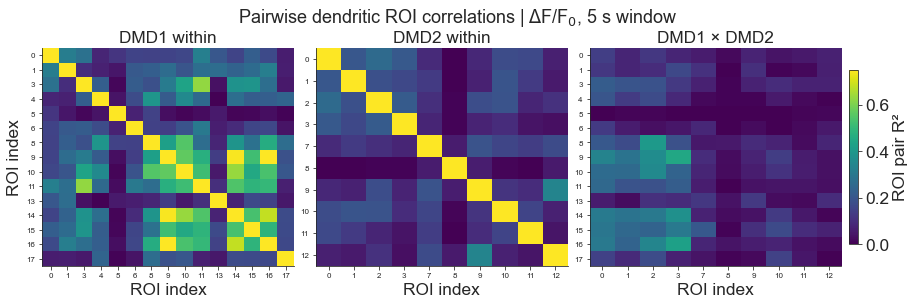

In [65]:
def _matrix_display_values(M, metric="r2", is_within=True, hide_diag=True):
    M = np.asarray(M, dtype=float)
    if metric == "r2":
        V = M ** 2
    elif metric == "r":
        V = M.copy()
    else:
        raise ValueError("metric must be 'r' or 'r2'")
    if is_within and hide_diag:
        V = V.copy()
        np.fill_diagonal(V, np.nan)
    return V


def plot_example_correlation_matrices(corrs, w, metric="r2", vmax=None, hide_diag=True):
    """Plot DMD1, DMD2, and first cross-DMD matrix for one window.

    Tick labels are simplified to integer ROI indices rather than full ROI IDs.
    """

    def _simple_roi_labels(dmd_key):
        """Return compact integer labels for a DMD's ROIs."""
        d = w["dmd"][dmd_key]

        # Prefer original/source ROI indices if available.
        for key in ["source_roi_indices", "roi_indices", "roi_index", "indices"]:
            if key in d:
                return [str(int(x)) for x in np.asarray(d[key]).ravel()]

        # Fallback: sequential integer labels matching displayed order.
        n = len(d["roi_ids"])
        return [str(i) for i in range(n)]

    panels = []

    for dmd, C in corrs["within"].items():
        labels = _simple_roi_labels(dmd)
        panels.append((f"{dmd} within", C, True, labels, labels))

    for (d1, d2), C in corrs["cross"].items():
        ylabels = _simple_roi_labels(d1)
        xlabels = _simple_roi_labels(d2)
        panels.append((f"{d1} × {d2}", C, False, ylabels, xlabels))

    # Prefer DMD1, DMD2, DMD1xDMD2 ordering when present.
    panels = panels[:3]

    vals = []
    for _, C, is_within, _, _ in panels:
        V = _matrix_display_values(C, metric=metric, is_within=is_within, hide_diag=hide_diag)
        vals.append(V[np.isfinite(V)].ravel())

    vals = np.concatenate([v for v in vals if len(v)]) if vals else np.array([1.0])

    if metric == "r2":
        vmin = 0.0
        if vmax is None:
            vmax = float(np.nanpercentile(vals, 95)) if len(vals) else 1.0
            vmax = max(vmax, 0.05)
        cmap = plt.get_cmap("viridis").copy()
        cbar_label = "ROI pair R²"
    else:
        if vmax is None:
            vmax = float(np.nanpercentile(np.abs(vals), 95)) if len(vals) else 1.0
            vmax = max(vmax, 0.05)
        vmin = -vmax
        cmap = plt.get_cmap("coolwarm").copy()
        cbar_label = "ROI pair r"

    cmap.set_bad("0.88")

    fig, axes = plt.subplots(
        1,
        len(panels),
        figsize=(4.2 * len(panels), 3.8),
        constrained_layout=True,
        
    )

    if len(panels) == 1:
        axes = [axes]

    ims = []
    for ax, (title, C, is_within, ylabels, xlabels) in zip(axes, panels):
        
        ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
        ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
        
        V = _matrix_display_values(C, metric=metric, is_within=is_within, hide_diag=hide_diag)

        im = ax.imshow(
            V,
            vmin=vmin,
            vmax=vmax,
            cmap=cmap,
            aspect="auto",
            interpolation="nearest",
        )
        ims.append(im)

        ax.set_title(title)
        ax.set_xlabel("ROI index")
        ax.set_ylabel("ROI index")

        ax.set_xticks(np.arange(len(xlabels)))
        ax.set_yticks(np.arange(len(ylabels)))
        ax.set_xticklabels(xlabels, rotation=0, fontsize=8)
        ax.set_yticklabels(ylabels, fontsize=8)

        ax.spines[["top", "right"]].set_visible(False)

    axes[1].set_ylabel(None)
    axes[-1].set_ylabel(None)
        
    cbar = fig.colorbar(ims[-1], ax=axes, shrink=0.8, location="right",pad=0.01)
    cbar.set_label(cbar_label)

    # Be robust to older loaded windows that may have start_sec=None from auto-selection.
    title_start_sec = w.get("start_sec", None)
    if title_start_sec is None:
        first_dmd = next(iter(w["dmd"]))
        title_start_sec = float(w["dmd"][first_dmd]["time_sec"][0])

    title_window_sec = w.get("window_sec", None)
    if title_window_sec is None:
        first_dmd = next(iter(w["dmd"]))
        tt = w["dmd"][first_dmd]["time_sec"]
        title_window_sec = float(tt[-1] - tt[0])

    fig.suptitle(
        f"Pairwise dendritic ROI correlations | \u0394F/F$_{0}$, "
        f"{title_window_sec:g} s window",
        y=1.075,
        fontsize=18,
    )

    return fig, axes


fig, axes = plot_example_correlation_matrices(example_corrs, example_window, metric=MATRIX_METRIC,vmax=0.75,hide_diag=False)
file_base = OUT_DIR / f"{today_str}_example_corr_matrices_session{SESSION_INDEX}_{EXAMPLE_WINDOW_SEC:g}s_{MATRIX_METRIC}"
save_figure(fig, str(file_base), formats=[".pdf", ".png"], dpi=300)
plt.show()

## Sanity check: top pairs from the example window

The matrix is easier to interpret if we immediately inspect the strongest pairs. This is not a same-neuron call; it is a triage table for later high-pass/residual/morphology checks.

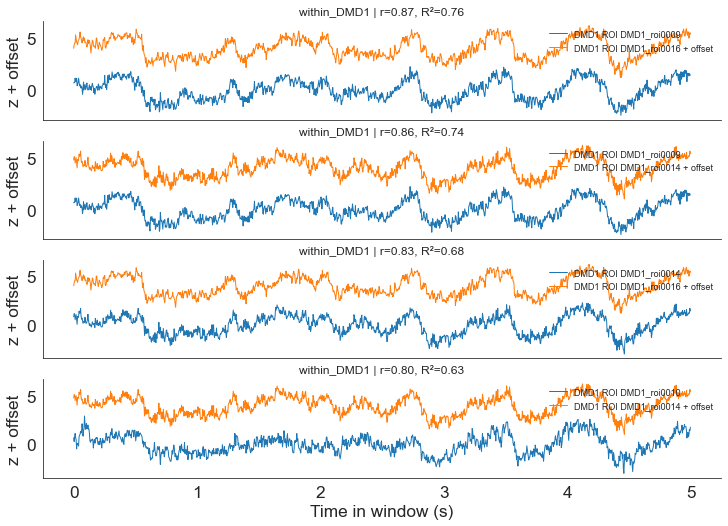

In [43]:
def plot_top_pair_traces(w, pair_df, n_pairs=4, window_sec=None):
    """Overlay z-scored traces for the strongest pairs in the loaded window."""
    top = pair_df.sort_values("r2", ascending=False).head(n_pairs).copy()
    fig, axes = plt.subplots(len(top), 1, figsize=(10, 1.8 * len(top)), sharex=True, constrained_layout=True)
    if len(top) == 1:
        axes = [axes]

    for ax, (_, p) in zip(axes, top.iterrows()):
        d1, d2 = p["dmd_a"], p["dmd_b"]
        # Find ROI positions in the loaded arrays by source ROI index.
        idx1 = np.where(w["dmd"][d1]["source_roi_indices"] == p["source_roi_a"])[0][0]
        idx2 = np.where(w["dmd"][d2]["source_roi_indices"] == p["source_roi_b"])[0][0]
        X1 = _zscore_rows(w["dmd"][d1]["X"][[idx1]])[0]
        X2 = _zscore_rows(w["dmd"][d2]["X"][[idx2]])[0]
        n = min(len(X1), len(X2), len(w["dmd"][d1]["time_sec"]))
        t = w["dmd"][d1]["time_sec"][:n] - w["dmd"][d1]["time_sec"][0]
        if window_sec is not None:
            keep = t <= window_sec
            t, X1, X2 = t[keep], X1[:n][keep], X2[:n][keep]
        ax.plot(t, X1[:len(t)], lw=1.0, label=f"{d1} ROI {p['roi_a']}")
        ax.plot(t, X2[:len(t)] + 4, lw=1.0, label=f"{d2} ROI {p['roi_b']} + offset")
        ax.set_ylabel("z + offset")
        ax.set_title(f"{p['pair_group']} | r={p['r']:.2f}, R²={p['r2']:.2f}", fontsize=12)
        ax.legend(frameon=False, fontsize=9, loc="upper right")
        ax.spines[["top", "right"]].set_visible(False)
    axes[-1].set_xlabel("Time in window (s)")
    return fig, axes

fig, axes = plot_top_pair_traces(example_window, example_pairs, n_pairs=4)
file_base = OUT_DIR / f"{today_str}_example_top_pair_traces_session{SESSION_INDEX}_{EXAMPLE_WINDOW_SEC:g}s"
save_figure(fig, str(file_base), formats=[".pdf", ".png"], dpi=300)
plt.show()

## Pooled correlation strength as a function of window length

Important design choice: do **not** pool all ROI pairs naively as independent observations. Sessions with more ROIs produce more pairs. The code below stores the full pair table, but the main summary is a session-level median for each DMD-pair group and window length.

In [44]:
def _common_time_range_for_signal(trace_h5, signal="dff"):
    with h5py.File(trace_h5, "r") as h5:
        dmds = [d for d in _get_dmd_keys(h5) if signal in h5[d]]
        if not dmds:
            return None, None
        t0 = max(float(h5[d]["timebase_sec"][0]) for d in dmds)
        t1 = min(float(h5[d]["timebase_sec"][-1]) for d in dmds)
    return t0, t1


def choose_window_starts(t0, t1, window_sec, n_windows=6, start_pad_sec=10.0, mode="even", rng=None):
    """Choose starts within the DMD-overlap time range."""
    rng = np.random.default_rng(RANDOM_SEED) if rng is None else rng
    lo = float(t0) + float(start_pad_sec)
    hi = float(t1) - float(window_sec)
    if hi <= lo:
        lo = float(t0)
        hi = float(t1) - float(window_sec)
    if hi <= lo:
        return []
    n = max(1, int(n_windows))
    if mode == "random":
        starts = np.sort(rng.uniform(lo, hi, size=n))
    else:
        starts = np.linspace(lo, hi, n) if n > 1 else np.array([(lo + hi) / 2])
    return [float(s) for s in starts]


def summarize_pair_table(pair_df):
    """Session/window/group summary used for plotting."""
    if pair_df.empty:
        return pd.DataFrame()
    key_cols = [
        "session_index", "subject_id", "session_id", "session_category",
        "window_sec", "window_start_sec", "pair_group",
    ]
    summary = (
        pair_df
        .groupby(key_cols, dropna=False)
        .agg(
            n_pairs=("r", "size"),
            median_r=("r", "median"),
            median_abs_r=("abs_r", "median"),
            median_r2=("r2", "median"),
            mean_r=("r", "mean"),
            mean_abs_r=("abs_r", "mean"),
            mean_r2=("r2", "mean"),
            q90_r2=("r2", lambda x: np.nanpercentile(x, 90)),
            max_r2=("r2", "max"),
        )
        .reset_index()
    )
    return summary


def run_window_correlation_sweep(
    assets,
    process_df,
    *,
    window_lengths_sec=(5.0, 30.0, 180.0),
    n_windows_per_length=6,
    max_sessions=None,
    signal="dff",
    target_fs_hz=250.0,
    valid_rois_only=True,
    robust_clip_z=8.0,
    start_mode="even",
    start_pad_sec=10.0,
    random_seed=0,
):
    rng = np.random.default_rng(random_seed)
    all_pairs = []
    logs = []

    session_indices = list(range(len(assets)))
    if max_sessions is not None:
        session_indices = session_indices[:int(max_sessions)]

    for si in session_indices:
        asset = assets[si]
        row = process_df.iloc[si]
        meta = session_metadata_from_row(row, session_index=si)
        try:
            trace_h5 = resolve_voltage_h5(asset)
            t0, t1 = _common_time_range_for_signal(trace_h5, signal=signal)
            if t0 is None:
                raise KeyError(f"signal {signal!r} not found")

            for win_sec in window_lengths_sec:
                starts = choose_window_starts(
                    t0, t1, win_sec,
                    n_windows=n_windows_per_length,
                    start_pad_sec=start_pad_sec,
                    mode=start_mode,
                    rng=rng,
                )
                for wi, start_sec in enumerate(starts):
                    w = load_voltage_window(
                        trace_h5,
                        signal=signal,
                        start_sec=start_sec,
                        window_sec=win_sec,
                        target_fs_hz=target_fs_hz,
                        valid_rois_only=valid_rois_only,
                        robust_clip_z=robust_clip_z,
                    )
                    corrs = compute_window_correlations(w)
                    pair_df = correlations_to_pair_table(
                        corrs,
                        w,
                        metadata={
                            **meta,
                            "trace_h5": str(trace_h5),
                            "window_sec": float(win_sec),
                            "window_index": int(wi),
                            "window_start_sec": float(start_sec),
                            "target_fs_hz": float(target_fs_hz),
                        },
                    )
                    all_pairs.append(pair_df)
                    logs.append({**meta, "window_sec": win_sec, "window_index": wi, "status": "ok", "n_pairs": len(pair_df)})
        except Exception as exc:
            logs.append({**meta, "status": "error", "error": repr(exc)})
            print(f"Session {si} failed: {exc}")

    pair_df_all = pd.concat(all_pairs, ignore_index=True) if all_pairs else pd.DataFrame()
    window_summary_df = summarize_pair_table(pair_df_all)

    # Session-level summary across sampled windows, so each session contributes once per window length/group.
    if not window_summary_df.empty:
        session_window_df = (
            window_summary_df
            .groupby(["session_index", "subject_id", "session_id", "session_category", "window_sec", "pair_group"], dropna=False)
            .agg(
                n_windows=("window_start_sec", "nunique"),
                n_pairs_total=("n_pairs", "sum"),
                median_r=("median_r", "median"),
                median_abs_r=("median_abs_r", "median"),
                median_r2=("median_r2", "median"),
                mean_r=("mean_r", "mean"),
                mean_abs_r=("mean_abs_r", "mean"),
                mean_r2=("mean_r2", "mean"),
                q90_r2=("q90_r2", "median"),
                max_r2=("max_r2", "median"),
            )
            .reset_index()
        )
    else:
        session_window_df = pd.DataFrame()

    return pair_df_all, window_summary_df, session_window_df, pd.DataFrame(logs)


pair_df_all, window_summary_df, session_window_df, sweep_log_df = run_window_correlation_sweep(
    assets,
    process_df,
    window_lengths_sec=WINDOW_LENGTHS_SEC,
    n_windows_per_length=N_WINDOWS_PER_LENGTH,
    max_sessions=MAX_SESSIONS,
    signal=SIGNAL,
    target_fs_hz=CORR_TARGET_FS_HZ,
    valid_rois_only=VALID_ROIS_ONLY,
    robust_clip_z=ROBUST_CLIP_Z,
    start_mode=WINDOW_START_MODE,
    start_pad_sec=START_PAD_SEC,
    random_seed=RANDOM_SEED,
)

display(sweep_log_df)
display(session_window_df.head())
print("pair_df_all shape:", pair_df_all.shape)
print("session_window_df shape:", session_window_df.shape)

,session_index,subject_id,session_id,session_date,session_category,window_sec,window_index,status,n_pairs
0,0,826031,826031_2026-01-30_15-04-02,2026-01-30,familiar,5.0,0,ok,300
1,0,826031,826031_2026-01-30_15-04-02,2026-01-30,familiar,5.0,1,ok,300
2,0,826031,826031_2026-01-30_15-04-02,2026-01-30,familiar,5.0,2,ok,300
3,0,826031,826031_2026-01-30_15-04-02,2026-01-30,familiar,5.0,3,ok,300
4,0,826031,826031_2026-01-30_15-04-02,2026-01-30,familiar,5.0,4,ok,300
...,...,...,...,...,...,...,...,...,...
337,18,826032,826032_2026-02-11_14-46-30,2026-02-11,novel+,180.0,1,ok,253
338,18,826032,826032_2026-02-11_14-46-30,2026-02-11,novel+,180.0,2,ok,253
339,18,826032,826032_2026-02-11_14-46-30,2026-02-11,novel+,180.0,3,ok,253
340,18,826032,826032_2026-02-11_14-46-30,2026-02-11,novel+,180.0,4,ok,253


,session_index,subject_id,session_id,session_category,window_sec,pair_group,n_windows,n_pairs_total,median_r,median_abs_r,median_r2,mean_r,mean_abs_r,mean_r2,q90_r2,max_r2
0,0,826031,826031_2026-01-30_15-04-02,familiar,5.0,cross_DMD1_DMD2,6,936,0.495133,0.495133,0.245230,0.431617,0.452146,0.248345,0.500164,0.684086
1,0,826031,826031_2026-01-30_15-04-02,familiar,5.0,within_DMD1,6,396,0.560945,0.560945,0.317113,0.543438,0.549558,0.356605,0.692893,0.818444
2,0,826031,826031_2026-01-30_15-04-02,familiar,5.0,within_DMD2,6,468,0.454944,0.454944,0.206983,0.399405,0.437818,0.235411,0.431650,0.641431
3,0,826031,826031_2026-01-30_15-04-02,familiar,30.0,cross_DMD1_DMD2,6,936,0.690583,0.690583,0.477216,0.529063,0.615876,0.435478,0.725096,0.860049
4,0,826031,826031_2026-01-30_15-04-02,familiar,30.0,within_DMD1,6,396,0.730623,0.730623,0.533859,0.636999,0.681882,0.522435,0.837235,0.889669


pair_df_all shape: (112050, 20)
session_window_df shape: (171, 16)


In [45]:
# Save tables for follow-up analysis and for making the slide outside Python if desired.
pair_csv = OUT_DIR / f"{today_str}_pairwise_roi_correlations_all_pairs.csv"
summary_csv = OUT_DIR / f"{today_str}_pairwise_roi_correlations_session_window_summary.csv"
log_csv = OUT_DIR / f"{today_str}_pairwise_roi_correlations_sweep_log.csv"

if not pair_df_all.empty:
    pair_df_all.to_csv(pair_csv, index=False)
if not session_window_df.empty:
    session_window_df.to_csv(summary_csv, index=False)
if not sweep_log_df.empty:
    sweep_log_df.to_csv(log_csv, index=False)

print("Saved:")
print(pair_csv)
print(summary_csv)
print(log_csv)

Saved:
C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\asap7_signal_correlations\2026-07-08_pairwise_roi_correlations_all_pairs.csv
C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\asap7_signal_correlations\2026-07-08_pairwise_roi_correlations_session_window_summary.csv
C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\asap7_signal_correlations\2026-07-08_pairwise_roi_correlations_sweep_log.csv


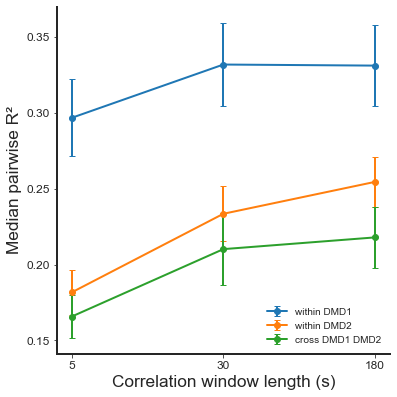

In [63]:
def _sem(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) <= 1:
        return np.nan
    return float(np.nanstd(x, ddof=1) / np.sqrt(len(x)))


def plot_corr_vs_window(session_window_df, metric="median_r2", facet_by="session_category"):
    """Plot session-level correlation strength vs window length."""
    df = session_window_df.copy()
    if df.empty:
        raise ValueError("session_window_df is empty. Run the sweep first.")

    # Nice ordering for slide readability.
    group_order = [g for g in ["within_DMD1", "within_DMD2", "cross_DMD1_DMD2"] if g in set(df["pair_group"])]
    group_order += [g for g in sorted(df["pair_group"].unique()) if g not in group_order]

    if facet_by is not None and facet_by in df.columns:
        categories = [c for c in ["familiar", "novel", "novel+"] if c in set(df[facet_by])]
        categories += [c for c in sorted(df[facet_by].dropna().unique()) if c not in categories]
    else:
        categories = ["all"]
        df["all"] = "all"
        facet_by = "all"

    fig, axes = plt.subplots(1, len(categories), figsize=(5.4 * len(categories), 5.4), sharey=True, constrained_layout=True)

    if len(categories) == 1:
        axes = [axes]

    for ax, cat in zip(axes, categories):
        ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
        ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
        for spine in ['left','bottom']:
            ax.spines[spine].set_linewidth(2)
        sub = df[df[facet_by] == cat]
        for group in group_order:
            gdf = sub[sub["pair_group"] == group]
            if gdf.empty:
                continue
            stats = (
                gdf.groupby("window_sec")
                .agg(mean=(metric, "mean"), sem=(metric, _sem), n=(metric, "count"))
                .reset_index()
                .sort_values("window_sec")
            )
            ax.errorbar(stats["window_sec"], stats["mean"], yerr=stats["sem"], marker="o", lw=2, capsize=3, label=group.replace("_", " "))
            # individual session medians
#             ax.scatter(gdf["window_sec"], gdf[metric], s=25, alpha=0.45)

        ax.set_xscale("log")
        ax.set_xticks(sorted(df["window_sec"].unique()))
        ax.set_xticklabels([f"{x:g}" for x in sorted(df["window_sec"].unique())])
        ax.set_xlabel("Correlation window length (s)")
#         ax.set_title(str(cat))
        ax.spines[["top", "right"]].set_visible(False)
#         ax.grid(axis="y", alpha=0.2)

    ylabel = {
        "median_r2": "Median pairwise R²",
        "median_abs_r": "Median |pairwise r|",
        "median_r": "Median pairwise r",
        "mean_r2": "Mean pairwise R²",
        "q90_r2": "90th percentile pairwise R²",
    }.get(metric, metric)
    axes[0].set_ylabel(ylabel)
    axes[-1].legend(frameon=False, fontsize=10, loc="best")
#     fig.suptitle("Shared dendritic voltage structure depends on the correlation timescale", y=1.05)
    return fig, axes


fig, axes = plot_corr_vs_window(session_window_df, metric='median_r2', facet_by="all")
file_base = OUT_DIR / f"{today_str}_pooled_corr_vs_window_{'median_r2'}_allsessions"
save_figure(fig, str(file_base), formats=[".pdf", ".png"], dpi=300)
plt.show()

## Optional control: circular time-shift null for the example window

A time-shift null preserves each ROI's marginal statistics and autocorrelation approximately, but destroys simultaneity between ROIs. This is a useful first control for whether the observed pairwise correlations are more than expected from slow autocorrelated traces alone.

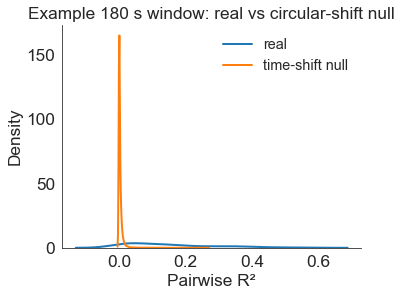

In [83]:
def circular_shift_null_pairs(w, n_shifts=50, min_shift_frac=0.2, random_seed=0):
    rng = np.random.default_rng(random_seed)
    null_tables = []

    for k in range(n_shifts):
        w_shift = {**w, "dmd": {}}
        for dmd, d in w["dmd"].items():
            X = d["X"].copy()
            n = X.shape[1]
            min_shift = int(max(1, min_shift_frac * n))
            for i in range(X.shape[0]):
                sh = int(rng.integers(min_shift, max(min_shift + 1, n - min_shift))) if n > 2 * min_shift else int(rng.integers(1, n))
                X[i] = np.roll(X[i], sh)
            w_shift["dmd"][dmd] = {**d, "X": X}
        corrs_shift = compute_window_correlations(w_shift)
        df = correlations_to_pair_table(corrs_shift, w_shift, metadata={"shift_index": k})
        null_tables.append(df)

    return pd.concat(null_tables, ignore_index=True) if null_tables else pd.DataFrame()


null_pairs = circular_shift_null_pairs(example_window, n_shifts=50, random_seed=RANDOM_SEED)
real_pairs = example_pairs.copy()
real_pairs["kind"] = "real"
null_pairs["kind"] = "time-shift null"

fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
for kind, df in [("real", real_pairs), ("time-shift null", null_pairs)]:
    vals = df["r2"].to_numpy(dtype=float)
    vals = vals[np.isfinite(vals)]
    if len(vals):
        sns.kdeplot(vals, ax=ax, label=kind, lw=2)
ax.set_xlabel("Pairwise R²")
ax.set_ylabel("Density")
ax.set_title(f"Example {EXAMPLE_WINDOW_SEC:g} s window: real vs circular-shift null")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)

file_base = OUT_DIR / f"{today_str}_example_timeshift_null_session{SESSION_INDEX}_{EXAMPLE_WINDOW_SEC:g}s"
save_figure(fig, str(file_base), formats=[".pdf", ".png"], dpi=300)
plt.show()

## Optional sensitivity analysis: DMD common-mode residualization

This is a deliberately conservative diagnostic. It asks how much pairwise structure remains after each ROI is linearly residualized against the leave-one-out mean trace from its own DMD. This can remove technical/common optical structure, but it can also remove real global biological state. Treat it as a sensitivity check, not a default preprocessing step.

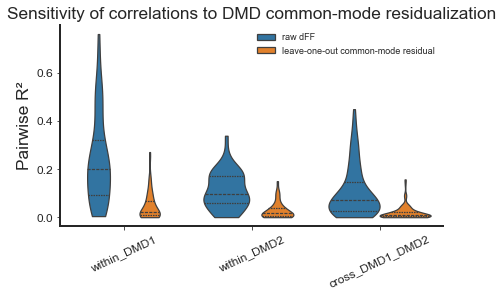

In [72]:
def residualize_against_leave_one_out_common_mode(X):
    X = np.asarray(X, dtype=np.float64)
    n_rois, n_time = X.shape
    if n_rois < 3:
        return X - np.nanmean(X, axis=1, keepdims=True)
    Xr = np.zeros_like(X)
    sum_x = np.nansum(X, axis=0)
    for i in range(n_rois):
        cm = (sum_x - X[i]) / max(n_rois - 1, 1)
        x = X[i] - np.nanmean(X[i])
        cm = cm - np.nanmean(cm)
        denom = np.dot(cm, cm)
        beta = np.dot(x, cm) / denom if denom > 0 else 0.0
        Xr[i] = x - beta * cm
    return Xr.astype(np.float32)


def residualize_window_common_mode(w):
    wr = {**w, "dmd": {}}
    for dmd, d in w["dmd"].items():
        wr["dmd"][dmd] = {**d, "X": residualize_against_leave_one_out_common_mode(d["X"])}
    return wr


example_window_resid = residualize_window_common_mode(example_window)
example_corrs_resid = compute_window_correlations(example_window_resid)
example_pairs_resid = correlations_to_pair_table(
    example_corrs_resid,
    example_window_resid,
    metadata={**session_metadata_from_row(row, SESSION_INDEX), "window_sec": 5, "window_start_sec": example_window["start_sec"], "preprocessing": "loo_common_mode_residual"},
)

plot_df = pd.concat([
    example_pairs.assign(preprocessing="raw dFF"),
    example_pairs_resid.assign(preprocessing="leave-one-out common-mode residual"),
], ignore_index=True)

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)
sns.violinplot(data=plot_df, x="pair_group", y="r2", hue="preprocessing", cut=0, inner="quartile", ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Pairwise R²")
ax.set_title("Sensitivity of correlations to DMD common-mode residualization")
ax.tick_params(axis="x", rotation=25)
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

file_base = OUT_DIR / f"{today_str}_example_common_mode_residualization_session{SESSION_INDEX}_{EXAMPLE_WINDOW_SEC:g}s"
save_figure(fig, str(file_base), formats=[".pdf", ".png"], dpi=300)
plt.show()


# Frequency-domain shared structure

These cells extend the pairwise correlation analysis by asking **which frequency bands carry shared ROI structure**. They leave the earlier analysis untouched and append three slide-oriented outputs:

1. a conceptual frequency-band schematic,
2. a representative single-session frequency decomposition,
3. an across-session summary of band-limited pairwise correlations.

Interpretation guardrail: band-limited correlation still measures sharedness, not mechanism. Slow shared bands can reflect biology, running/arousal, stimulus timing, motion, F₀ structure, or optical/electrical common mode. Faster residual/shared bands are better candidates for pair-specific dendritic or same-cell structure, but still need morphology and controls.


In [102]:

# ---------------------------------------------------------------------
# Frequency-domain analysis configuration
# ---------------------------------------------------------------------

FREQ_OUT_DIR = OUT_DIR / "frequency_shared_structure"
FREQ_OUT_DIR.mkdir(parents=True, exist_ok=True)

# 250 Hz is enough to analyze up to ~100 Hz while keeping the sweep fast.
# Increase FREQ_TARGET_FS_HZ if you want to push higher-frequency bands later.
FREQ_EXAMPLE_WINDOW_SEC = 180.0
FREQ_EXAMPLE_START_SEC = EXAMPLE_START_SEC
FREQ_TARGET_FS_HZ = 250.0
FREQ_N_WINDOWS_PER_SESSION = 3
FREQ_MAX_SESSIONS = MAX_SESSIONS

# Broad, first-pass bands. The lowest band should contain multiple cycles in the analysis window.
FREQ_BANDS_HZ = [
    {"band_order": 0, "band_key": "very_slow", "band_label": "0.05-0.5 Hz", "low_hz": 0.05, "high_hz": 0.5, "interpretation": "slow state / drift / F0"},
    {"band_order": 1, "band_key": "slow",      "band_label": "0.5-2 Hz",    "low_hz": 0.5,  "high_hz": 2.0, "interpretation": "running / arousal / slow network"},
    {"band_order": 2, "band_key": "task",      "band_label": "2-8 Hz",      "low_hz": 2.0,  "high_hz": 8.0, "interpretation": "visual/task-scale fluctuations"},
    {"band_order": 3, "band_key": "mid",       "band_label": "8-30 Hz",     "low_hz": 8.0,  "high_hz": 30.0, "interpretation": "faster subthreshold/network"},
    {"band_order": 4, "band_key": "fast",      "band_label": ">30 Hz",   "low_hz": 30.0, "high_hz": 600.0, "interpretation": "fast pair-specific/candidate same-cell"},
]

FREQ_MIN_CYCLES_PER_BAND = 3.0
FREQ_FILTER_ORDER = 4
FREQ_SUMMARY_METRIC = "median_r2"

print("Frequency output directory:", FREQ_OUT_DIR)
display(pd.DataFrame(FREQ_BANDS_HZ))


Frequency output directory: C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\asap7_signal_correlations\frequency_shared_structure


,band_order,band_key,band_label,low_hz,high_hz,interpretation
0,0,very_slow,0.05-0.5 Hz,0.05,0.5,slow state / drift / F0
1,1,slow,0.5-2 Hz,0.50,2.0,running / arousal / slow network
2,2,task,2-8 Hz,2.00,8.0,visual/task-scale fluctuations
3,3,mid,8-30 Hz,8.00,30.0,faster subthreshold/network
4,4,fast,>30 Hz,30.00,600.0,fast pair-specific/candidate same-cell


In [103]:

# ---------------------------------------------------------------------
# Frequency-domain helper functions
# ---------------------------------------------------------------------

def _window_fs_hz(w):
    """Estimate sampling rate from a loaded window."""
    first_dmd = next(iter(w["dmd"]))
    t = np.asarray(w["dmd"][first_dmd]["time_sec"], dtype=float)
    dt = np.diff(t)
    dt = dt[np.isfinite(dt) & (dt > 0)]
    if len(dt) == 0:
        return np.nan
    return float(1.0 / np.nanmedian(dt))


def _band_is_valid_for_window(low_hz, high_hz, fs_hz, duration_sec, min_cycles=3.0):
    """Check that a band is feasible for the loaded sampling rate and window length."""
    if not np.isfinite(fs_hz) or fs_hz <= 0:
        return False, "invalid fs"
    nyq = fs_hz / 2.0
    if high_hz >= 0.98 * nyq:
        return False, f"high cutoff {high_hz:g} Hz too close to Nyquist {nyq:g} Hz"
    if low_hz <= 0 or low_hz >= high_hz:
        return False, "invalid band limits"
    if duration_sec * low_hz < min_cycles:
        return False, f"too few low-frequency cycles: {duration_sec * low_hz:.1f}"
    return True, "ok"


def _bandpass_rows(X, fs_hz, low_hz, high_hz, order=4):
    """Zero-phase band-pass filter ROI-major traces."""
    X = np.asarray(X, dtype=np.float64)
    if X.ndim != 2:
        raise ValueError("Expected ROI-major 2D array: n_rois x n_time")

    nyq = fs_hz / 2.0
    low = float(low_hz) / nyq
    high = float(high_hz) / nyq
    if not (0 < low < high < 1):
        raise ValueError(f"Invalid normalized band: low={low:.3g}, high={high:.3g}, fs={fs_hz:.3g}")

    # Remove linear trends before filtering so very slow drift does not dominate edges.
    Xd = scipy_signal.detrend(X, axis=1, type="linear")
    sos = scipy_signal.butter(order, [low, high], btype="bandpass", output="sos")

    default_padlen = 3 * (2 * len(sos) + 1)
    padlen = min(default_padlen, max(0, Xd.shape[1] - 1))
    if padlen < 1:
        return np.full_like(Xd, np.nan, dtype=np.float32)

    Xf = scipy_signal.sosfiltfilt(sos, Xd, axis=1, padlen=padlen)
    return Xf.astype(np.float32)


def bandpass_window(w, band, *, order=4, min_cycles=3.0):
    """Return a copy of a loaded window with each DMD trace band-pass filtered."""
    fs_hz = _window_fs_hz(w)
    low_hz = float(band["low_hz"])
    high_hz = float(band["high_hz"])

    first_dmd = next(iter(w["dmd"]))
    tt = np.asarray(w["dmd"][first_dmd]["time_sec"], dtype=float)
    duration_sec = float(tt[-1] - tt[0]) if len(tt) else np.nan

    ok, reason = _band_is_valid_for_window(
        low_hz, high_hz, fs_hz, duration_sec, min_cycles=min_cycles
    )
    if not ok:
        raise ValueError(f"Skipping band {band['band_label']}: {reason}")

    wb = {**w, "dmd": {}, "frequency_band": dict(band), "fs_hz": fs_hz}
    for dmd, d in w["dmd"].items():
        Xf = _bandpass_rows(d["X"], fs_hz, low_hz, high_hz, order=order)
        wb["dmd"][dmd] = {**d, "X": Xf}
    return wb


def compute_band_correlation_table(w, bands=FREQ_BANDS_HZ, *, metadata=None, order=4, min_cycles=3.0):
    """Compute pairwise correlations after band-pass filtering a loaded window."""
    metadata = {} if metadata is None else dict(metadata)
    tables = []
    log_rows = []

    for band in bands:
        try:
            wb = bandpass_window(w, band, order=order, min_cycles=min_cycles)
            corrs = compute_window_correlations(wb)
            df = correlations_to_pair_table(
                corrs,
                wb,
                metadata={
                    **metadata,
                    "band_order": int(band["band_order"]),
                    "band_key": band["band_key"],
                    "band_label": band["band_label"],
                    "band_low_hz": float(band["low_hz"]),
                    "band_high_hz": float(band["high_hz"]),
                    "band_interpretation": band.get("interpretation", ""),
                    "fs_hz": float(wb["fs_hz"]),
                },
            )
            tables.append(df)
            log_rows.append({**metadata, **band, "status": "ok", "n_pairs": len(df)})
        except Exception as exc:
            log_rows.append({**metadata, **band, "status": "error", "error": repr(exc)})
            print(f"Band {band.get('band_label')} failed: {exc}")

    pair_df = pd.concat(tables, ignore_index=True) if tables else pd.DataFrame()
    log_df = pd.DataFrame(log_rows)
    return pair_df, log_df


def summarize_frequency_pair_table(freq_pair_df):
    """Summarize band-limited pairwise correlations at the session/window/group/band level."""
    if freq_pair_df.empty:
        return pd.DataFrame()

    key_cols = [
        "session_index", "subject_id", "session_id", "session_category",
        "window_sec", "window_start_sec", "window_index",
        "band_order", "band_key", "band_label", "band_low_hz", "band_high_hz",
        "pair_group",
    ]
    key_cols = [c for c in key_cols if c in freq_pair_df.columns]

    return (
        freq_pair_df
        .groupby(key_cols, dropna=False)
        .agg(
            n_pairs=("r", "size"),
            median_r=("r", "median"),
            median_abs_r=("abs_r", "median"),
            median_r2=("r2", "median"),
            mean_r=("r", "mean"),
            mean_abs_r=("abs_r", "mean"),
            mean_r2=("r2", "mean"),
            q25_r2=("r2", lambda x: np.nanpercentile(x, 25)),
            q75_r2=("r2", lambda x: np.nanpercentile(x, 75)),
            q90_r2=("r2", lambda x: np.nanpercentile(x, 90)),
            max_r2=("r2", "max"),
        )
        .reset_index()
        .sort_values(["band_order", "pair_group"])
    )


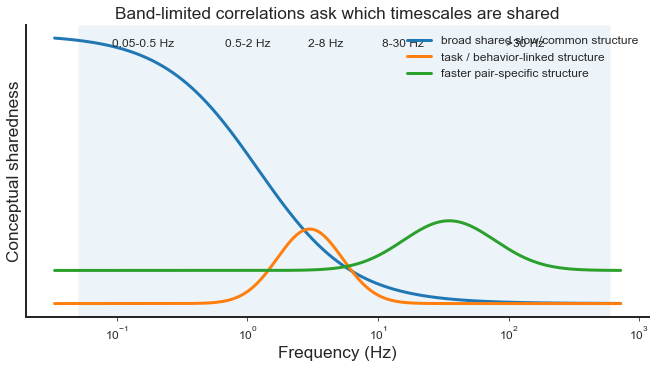

In [104]:

def plot_frequency_band_concept(bands=FREQ_BANDS_HZ):
    """Schematic for the slide: which timescales might carry shared structure?"""
    fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
    ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
    ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
    f_min = min(b["low_hz"] for b in bands) / 1.5
    f_max = max(b["high_hz"] for b in bands) * 1.2
    x = np.logspace(np.log10(f_min), np.log10(f_max), 600)

    # Conceptual curves only; not fit to data.
    broad_common = 0.65 / (1 + (x / 1.2) ** 1.2)
    task_scale = 0.18 * np.exp(-0.5 * ((np.log10(x) - np.log10(3.0)) / 0.25) ** 2)
    pair_specific = 0.08 + 0.12 * np.exp(-0.5 * ((np.log10(x) - np.log10(35.0)) / 0.35) ** 2)

    ax.plot(x, broad_common, lw=3, label="broad shared slow/common structure")
    ax.plot(x, task_scale, lw=3, label="task / behavior-linked structure")
    ax.plot(x, pair_specific, lw=3, label="faster pair-specific structure")

    ylim = ax.get_ylim()
    for b in bands:
        lo, hi = b["low_hz"], b["high_hz"]
        xc = np.sqrt(lo * hi)
        ax.axvspan(lo, hi, alpha=0.08)
        ax.text(
            xc,
            ylim[1] * 0.95,
            b["band_label"],
            ha="center",
            va="top",
            fontsize=12,
            rotation=0,
        )

    ax.set_xscale("log")
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Conceptual sharedness")
    ax.set_title("Band-limited correlations ask which timescales are shared")
    ax.legend(frameon=False, fontsize=12, loc="best")
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_yticks([])
    
    for spine in ['left','bottom']:
        ax.spines[spine].set_linewidth(2)
    
    return fig, ax


fig, ax = plot_frequency_band_concept()
file_base = FREQ_OUT_DIR / f"{today_str}_frequency_band_concept"
save_figure(fig, str(file_base), formats=[".pdf", ".png"], dpi=300)
plt.show()


In [105]:

# Representative single-session frequency analysis.
freq_asset = assets[SESSION_INDEX]
freq_row = process_df.iloc[SESSION_INDEX]
freq_trace_h5 = resolve_voltage_h5(freq_asset)

freq_example_window = load_voltage_window(
    freq_trace_h5,
    signal=SIGNAL,
    start_sec=FREQ_EXAMPLE_START_SEC,
    window_sec=FREQ_EXAMPLE_WINDOW_SEC,
    target_fs_hz=FREQ_TARGET_FS_HZ,
    valid_rois_only=VALID_ROIS_ONLY,
    robust_clip_z=ROBUST_CLIP_Z,
)

freq_example_metadata = {
    **session_metadata_from_row(freq_row, SESSION_INDEX),
    "trace_h5": str(freq_trace_h5),
    "window_sec": float(FREQ_EXAMPLE_WINDOW_SEC),
    "window_index": 0,
    "window_start_sec": float(freq_example_window["start_sec"]),
    "target_fs_hz": float(FREQ_TARGET_FS_HZ),
}

freq_example_pairs, freq_example_log = compute_band_correlation_table(
    freq_example_window,
    bands=FREQ_BANDS_HZ,
    metadata=freq_example_metadata,
    order=FREQ_FILTER_ORDER,
    min_cycles=FREQ_MIN_CYCLES_PER_BAND,
)

freq_example_summary = summarize_frequency_pair_table(freq_example_pairs)

display(freq_example_log)
display(freq_example_summary.head(20))
print("freq_example_pairs shape:", freq_example_pairs.shape)


,session_index,subject_id,session_id,session_date,session_category,trace_h5,window_sec,window_index,window_start_sec,target_fs_hz,band_order,band_key,band_label,low_hz,high_hz,interpretation,status,n_pairs
0,1,826031,826031_2026-02-01_11-01-50,2026-02-01,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,180.0,0,24.734976,250.0,0,very_slow,0.05-0.5 Hz,0.05,0.5,slow state / drift / F0,ok,300
1,1,826031,826031_2026-02-01_11-01-50,2026-02-01,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,180.0,0,24.734976,250.0,1,slow,0.5-2 Hz,0.50,2.0,running / arousal / slow network,ok,300
2,1,826031,826031_2026-02-01_11-01-50,2026-02-01,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,180.0,0,24.734976,250.0,2,task,2-8 Hz,2.00,8.0,visual/task-scale fluctuations,ok,300
3,1,826031,826031_2026-02-01_11-01-50,2026-02-01,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,180.0,0,24.734976,250.0,3,mid,8-30 Hz,8.00,30.0,faster subthreshold/network,ok,300
4,1,826031,826031_2026-02-01_11-01-50,2026-02-01,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,180.0,0,24.734976,250.0,4,fast,>30 Hz,30.00,600.0,fast pair-specific/candidate same-cell,ok,300


,session_index,subject_id,session_id,session_category,window_sec,window_start_sec,window_index,band_order,band_key,band_label,...,median_r,median_abs_r,median_r2,mean_r,mean_abs_r,mean_r2,q25_r2,q75_r2,q90_r2,max_r2
0,1,826031,826031_2026-02-01_11-01-50,familiar,180.0,24.734976,0,0,very_slow,0.05-0.5 Hz,...,0.292046,0.330086,0.108970,0.225837,0.345494,0.167146,0.023500,0.270780,0.399851,0.657272
1,1,826031,826031_2026-02-01_11-01-50,familiar,180.0,24.734976,0,0,very_slow,0.05-0.5 Hz,...,0.480897,0.480897,0.231262,0.425908,0.470031,0.282687,0.084812,0.461072,0.609687,0.798099
2,1,826031,826031_2026-02-01_11-01-50,familiar,180.0,24.734976,0,0,very_slow,0.05-0.5 Hz,...,0.686129,0.686129,0.470773,0.653392,0.653392,0.464619,0.245671,0.695562,0.754901,0.847524
3,1,826031,826031_2026-02-01_11-01-50,familiar,180.0,24.734976,0,1,slow,0.5-2 Hz,...,0.413651,0.413651,0.171107,0.385418,0.408486,0.202339,0.083507,0.263175,0.430554,0.843958
4,1,826031,826031_2026-02-01_11-01-50,familiar,180.0,24.734976,0,1,slow,0.5-2 Hz,...,0.536362,0.536362,0.287684,0.559887,0.559887,0.336261,0.208420,0.444880,0.607756,0.881058
5,1,826031,826031_2026-02-01_11-01-50,familiar,180.0,24.734976,0,1,slow,0.5-2 Hz,...,0.577008,0.577008,0.332938,0.517083,0.518008,0.323180,0.173065,0.473092,0.584935,0.812743
6,1,826031,826031_2026-02-01_11-01-50,familiar,180.0,24.734976,0,2,task,2-8 Hz,...,0.172358,0.185633,0.034463,0.189797,0.213663,0.069138,0.006164,0.107688,0.170968,0.387703
7,1,826031,826031_2026-02-01_11-01-50,familiar,180.0,24.734976,0,2,task,2-8 Hz,...,0.357632,0.357632,0.127900,0.357634,0.358003,0.156806,0.057967,0.234314,0.327790,0.605606
8,1,826031,826031_2026-02-01_11-01-50,familiar,180.0,24.734976,0,2,task,2-8 Hz,...,0.445753,0.445753,0.198696,0.440045,0.440045,0.213675,0.114134,0.299958,0.374963,0.519468
9,1,826031,826031_2026-02-01_11-01-50,familiar,180.0,24.734976,0,3,mid,8-30 Hz,...,0.037221,0.055550,0.003086,0.024842,0.066112,0.006868,0.000795,0.008064,0.014726,0.069646


freq_example_pairs shape: (1500, 27)


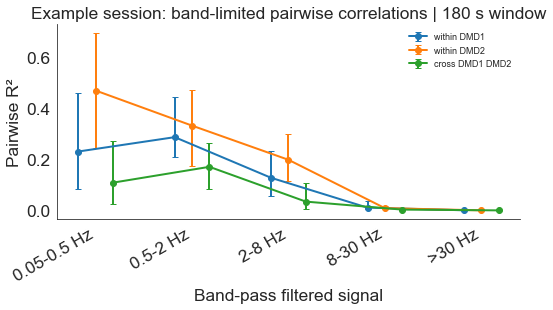

In [106]:

def _ordered_pair_groups(df):
    order = [g for g in ["within_DMD1", "within_DMD2", "cross_DMD1_DMD2"] if g in set(df["pair_group"])]
    order += [g for g in sorted(df["pair_group"].dropna().unique()) if g not in order]
    return order


def plot_frequency_pair_summary(freq_pair_df, *, title=None, metric="r2"):
    """Plot median pairwise band-limited R2 for one session/window."""
    if freq_pair_df.empty:
        raise ValueError("freq_pair_df is empty")

    df = freq_pair_df.copy()
    band_order = (
        df[["band_order", "band_label"]]
        .drop_duplicates()
        .sort_values("band_order")
    )
    labels = band_order["band_label"].tolist()
    x = np.arange(len(labels))

    group_order = _ordered_pair_groups(df)
    offsets = np.linspace(-0.18, 0.18, max(len(group_order), 1))

    fig, ax = plt.subplots(figsize=(7.2, 4.2), constrained_layout=True)
    for off, group in zip(offsets, group_order):
        sub = df[df["pair_group"] == group]
        stats = (
            sub.groupby(["band_order", "band_label"])
            .agg(
                med=(metric, "median"),
                q25=(metric, lambda v: np.nanpercentile(v, 25)),
                q75=(metric, lambda v: np.nanpercentile(v, 75)),
                n=(metric, "size"),
            )
            .reset_index()
            .sort_values("band_order")
        )
        y = stats["med"].to_numpy(dtype=float)
        yerr = np.vstack([
            y - stats["q25"].to_numpy(dtype=float),
            stats["q75"].to_numpy(dtype=float) - y,
        ])
        ax.errorbar(
            stats["band_order"].to_numpy(dtype=float) + off,
            y,
            yerr=yerr,
            marker="o",
            lw=2,
            capsize=3,
            label=group.replace("_", " "),
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha="right")
    ax.set_xlabel("Band-pass filtered signal")
    ax.set_ylabel("Pairwise R²" if metric == "r2" else metric)
    if title is not None:
        ax.set_title(title)
    ax.legend(frameon=False, fontsize=9, loc="best")
    ax.spines[["top", "right"]].set_visible(False)
    return fig, ax


fig, ax = plot_frequency_pair_summary(
    freq_example_pairs,
    title=f"Example session: band-limited pairwise correlations | {FREQ_EXAMPLE_WINDOW_SEC:g} s window",
    metric="r2",
)
file_base = FREQ_OUT_DIR / f"{today_str}_example_bandlimited_pairwise_r2_session{SESSION_INDEX}"
save_figure(fig, str(file_base), formats=[".pdf", ".png"], dpi=300)
plt.show()


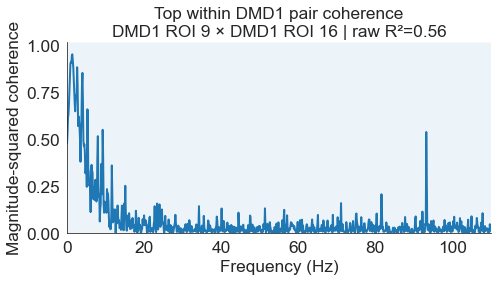

,session_index,subject_id,session_id,session_date,session_category,window_sec,window_start_sec,pair_group,dmd_a,dmd_b,roi_a,roi_b,source_roi_a,source_roi_b,r,abs_r,r2
82,1,826031,826031_2026-02-01_11-01-50,2026-02-01,familiar,180,24.734976,within_DMD1,DMD1,DMD1,DMD1_roi0009,DMD1_roi0016,9,16,0.746806,0.746806,0.557719


In [107]:

def _extract_pair_traces_from_window(w, pair_row):
    """Return time and two ROI traces for a pair-table row."""
    d1, d2 = pair_row["dmd_a"], pair_row["dmd_b"]
    idx1 = np.where(w["dmd"][d1]["source_roi_indices"] == pair_row["source_roi_a"])[0][0]
    idx2 = np.where(w["dmd"][d2]["source_roi_indices"] == pair_row["source_roi_b"])[0][0]
    x1 = np.asarray(w["dmd"][d1]["X"][idx1], dtype=float)
    x2 = np.asarray(w["dmd"][d2]["X"][idx2], dtype=float)
    t = np.asarray(w["dmd"][d1]["time_sec"], dtype=float)
    n = min(len(t), len(x1), len(x2))
    return t[:n], x1[:n], x2[:n]


def plot_top_pair_coherence(w, pair_df, *, pair_group="within_DMD1", bands=FREQ_BANDS_HZ, max_freq_hz=600.0):
    """Plot magnitude-squared coherence for the strongest raw pair in a group."""
    sub = pair_df[pair_df["pair_group"] == pair_group].copy()
    if sub.empty:
        sub = pair_df.copy()
    top = sub.sort_values("r2", ascending=False).iloc[0]
    t, x1, x2 = _extract_pair_traces_from_window(w, top)
    fs_hz = _window_fs_hz(w)

    x1 = scipy_signal.detrend(x1, type="linear")
    x2 = scipy_signal.detrend(x2, type="linear")
    nperseg = min(len(x1), int(round(fs_hz * 8)))
    nperseg = max(256, nperseg) if len(x1) >= 256 else len(x1)
    f, coh = scipy_signal.coherence(x1, x2, fs=fs_hz, nperseg=nperseg)

    fig, ax = plt.subplots(figsize=(6.8, 3.8), constrained_layout=True)
    for b in bands:
        ax.axvspan(b["low_hz"], b["high_hz"], alpha=0.08)
    ax.plot(f, coh, lw=2)
    ax.set_xlim(0, min(max_freq_hz, fs_hz / 2.0))
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("Frequency (Hz)")
    ax.set_ylabel("Magnitude-squared coherence")
    ax.set_title(
        f"Top {pair_group.replace('_', ' ')} pair coherence\n"
        f"{top['dmd_a']} ROI {top['source_roi_a']} × {top['dmd_b']} ROI {top['source_roi_b']} | raw R²={top['r2']:.2f}"
    )
    ax.spines[["top", "right"]].set_visible(False)
    return fig, ax, top


# Use the raw example_pairs from the earlier correlation-matrix cell to pick a visually relevant pair.
fig, ax, top_coh_pair = plot_top_pair_coherence(
    freq_example_window,
    example_pairs,
    pair_group="within_DMD1",
    bands=FREQ_BANDS_HZ,
)
file_base = FREQ_OUT_DIR / f"{today_str}_example_top_withinDMD1_pair_coherence_session{SESSION_INDEX}"
save_figure(fig, str(file_base), formats=[".pdf", ".png"], dpi=300)
plt.show()

display(pd.DataFrame([top_coh_pair]))


In [108]:

def run_frequency_correlation_sweep(
    assets,
    process_df,
    *,
    bands=FREQ_BANDS_HZ,
    window_sec=180.0,
    n_windows_per_session=3,
    max_sessions=None,
    signal="dff",
    target_fs_hz=250.0,
    valid_rois_only=True,
    robust_clip_z=8.0,
    start_mode="even",
    start_pad_sec=10.0,
    random_seed=0,
    filter_order=4,
    min_cycles=3.0,
):
    rng = np.random.default_rng(random_seed)
    all_pairs = []
    all_logs = []

    session_indices = list(range(len(assets)))
    if max_sessions is not None:
        session_indices = session_indices[:int(max_sessions)]

    for si in session_indices:
        asset = assets[si]
        row = process_df.iloc[si]
        meta = session_metadata_from_row(row, session_index=si)
        try:
            trace_h5 = resolve_voltage_h5(asset)
            t0, t1 = _common_time_range_for_signal(trace_h5, signal=signal)
            if t0 is None:
                raise KeyError(f"signal {signal!r} not found")

            starts = choose_window_starts(
                t0,
                t1,
                window_sec,
                n_windows=n_windows_per_session,
                start_pad_sec=start_pad_sec,
                mode=start_mode,
                rng=rng,
            )

            for wi, start_sec in enumerate(starts):
                w = load_voltage_window(
                    trace_h5,
                    signal=signal,
                    start_sec=start_sec,
                    window_sec=window_sec,
                    target_fs_hz=target_fs_hz,
                    valid_rois_only=valid_rois_only,
                    robust_clip_z=robust_clip_z,
                )
                pair_df, log_df = compute_band_correlation_table(
                    w,
                    bands=bands,
                    metadata={
                        **meta,
                        "trace_h5": str(trace_h5),
                        "window_sec": float(window_sec),
                        "window_index": int(wi),
                        "window_start_sec": float(start_sec),
                        "target_fs_hz": float(target_fs_hz),
                    },
                    order=filter_order,
                    min_cycles=min_cycles,
                )
                if not pair_df.empty:
                    all_pairs.append(pair_df)
                all_logs.append(log_df)
                print(f"session {si}, window {wi}: {len(pair_df)} band-limited pairs")
        except Exception as exc:
            all_logs.append(pd.DataFrame([{**meta, "status": "error", "error": repr(exc)}]))
            print(f"Session {si} failed: {exc}")

    freq_pair_df_all = pd.concat(all_pairs, ignore_index=True) if all_pairs else pd.DataFrame()
    freq_log_df = pd.concat(all_logs, ignore_index=True) if all_logs else pd.DataFrame()
    freq_window_summary_df = summarize_frequency_pair_table(freq_pair_df_all)

    if not freq_window_summary_df.empty:
        group_cols = [
            "session_index", "subject_id", "session_id", "session_category",
            "band_order", "band_key", "band_label", "band_low_hz", "band_high_hz",
            "pair_group",
        ]
        freq_session_band_df = (
            freq_window_summary_df
            .groupby(group_cols, dropna=False)
            .agg(
                n_windows=("window_index", "nunique"),
                n_pairs_total=("n_pairs", "sum"),
                median_r=("median_r", "median"),
                median_abs_r=("median_abs_r", "median"),
                median_r2=("median_r2", "median"),
                mean_r=("mean_r", "mean"),
                mean_abs_r=("mean_abs_r", "mean"),
                mean_r2=("mean_r2", "mean"),
                q25_r2=("q25_r2", "median"),
                q75_r2=("q75_r2", "median"),
                q90_r2=("q90_r2", "median"),
                max_r2=("max_r2", "median"),
            )
            .reset_index()
            .sort_values(["band_order", "pair_group"])
        )
    else:
        freq_session_band_df = pd.DataFrame()

    return freq_pair_df_all, freq_window_summary_df, freq_session_band_df, freq_log_df


freq_pair_df_all, freq_window_summary_df, freq_session_band_df, freq_sweep_log_df = run_frequency_correlation_sweep(
    assets,
    process_df,
    bands=FREQ_BANDS_HZ,
    window_sec=FREQ_EXAMPLE_WINDOW_SEC,
    n_windows_per_session=FREQ_N_WINDOWS_PER_SESSION,
    max_sessions=FREQ_MAX_SESSIONS,
    signal=SIGNAL,
    target_fs_hz=FREQ_TARGET_FS_HZ,
    valid_rois_only=VALID_ROIS_ONLY,
    robust_clip_z=ROBUST_CLIP_Z,
    start_mode=WINDOW_START_MODE,
    start_pad_sec=START_PAD_SEC,
    random_seed=RANDOM_SEED,
    filter_order=FREQ_FILTER_ORDER,
    min_cycles=FREQ_MIN_CYCLES_PER_BAND,
)

display(freq_sweep_log_df.tail())
display(freq_session_band_df.head())
print("freq_pair_df_all shape:", freq_pair_df_all.shape)
print("freq_session_band_df shape:", freq_session_band_df.shape)


session 0, window 0: 1500 band-limited pairs
session 0, window 1: 1500 band-limited pairs
session 0, window 2: 1500 band-limited pairs
session 1, window 0: 1500 band-limited pairs
session 1, window 1: 1500 band-limited pairs
session 1, window 2: 1500 band-limited pairs
session 2, window 0: 1625 band-limited pairs
session 2, window 1: 1625 band-limited pairs
session 2, window 2: 1625 band-limited pairs
session 3, window 0: 2030 band-limited pairs
session 3, window 1: 2030 band-limited pairs
session 3, window 2: 2030 band-limited pairs
session 4, window 0: 1500 band-limited pairs
session 4, window 1: 1500 band-limited pairs
session 4, window 2: 1500 band-limited pairs
session 5, window 0: 1050 band-limited pairs
session 5, window 1: 1050 band-limited pairs
session 5, window 2: 1050 band-limited pairs
session 6, window 0: 2175 band-limited pairs
session 6, window 1: 2175 band-limited pairs
session 6, window 2: 2175 band-limited pairs
session 7, window 0: 1265 band-limited pairs
session 7,

,session_index,subject_id,session_id,session_date,session_category,trace_h5,window_sec,window_index,window_start_sec,target_fs_hz,band_order,band_key,band_label,low_hz,high_hz,interpretation,status,n_pairs
280,18,826032,826032_2026-02-11_14-46-30,2026-02-11,novel+,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,180.0,2,1620.136323,250.0,0,very_slow,0.05-0.5 Hz,0.05,0.5,slow state / drift / F0,ok,253
281,18,826032,826032_2026-02-11_14-46-30,2026-02-11,novel+,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,180.0,2,1620.136323,250.0,1,slow,0.5-2 Hz,0.50,2.0,running / arousal / slow network,ok,253
282,18,826032,826032_2026-02-11_14-46-30,2026-02-11,novel+,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,180.0,2,1620.136323,250.0,2,task,2-8 Hz,2.00,8.0,visual/task-scale fluctuations,ok,253
283,18,826032,826032_2026-02-11_14-46-30,2026-02-11,novel+,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,180.0,2,1620.136323,250.0,3,mid,8-30 Hz,8.00,30.0,faster subthreshold/network,ok,253
284,18,826032,826032_2026-02-11_14-46-30,2026-02-11,novel+,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,180.0,2,1620.136323,250.0,4,fast,>30 Hz,30.00,600.0,fast pair-specific/candidate same-cell,ok,253


,session_index,subject_id,session_id,session_category,band_order,band_key,band_label,band_low_hz,band_high_hz,pair_group,...,median_r,median_abs_r,median_r2,mean_r,mean_abs_r,mean_r2,q25_r2,q75_r2,q90_r2,max_r2
0,0,826031,826031_2026-01-30_15-04-02,familiar,0,very_slow,0.05-0.5 Hz,0.05,0.5,cross_DMD1_DMD2,...,0.848080,0.848080,0.719243,0.580048,0.732614,0.601909,0.357931,0.862040,0.925415,0.962589
15,1,826031,826031_2026-02-01_11-01-50,familiar,0,very_slow,0.05-0.5 Hz,0.05,0.5,cross_DMD1_DMD2,...,0.655386,0.655386,0.429580,0.496794,0.539152,0.353612,0.266571,0.534403,0.636440,0.777861
30,2,826031,826031_2026-02-02_10-23-53,familiar,0,very_slow,0.05-0.5 Hz,0.05,0.5,cross_DMD1_DMD2,...,0.857885,0.857885,0.735966,0.842824,0.842824,0.713981,0.637780,0.789183,0.821872,0.876556
45,3,826031,826031_2026-02-03_14-21-45,familiar,0,very_slow,0.05-0.5 Hz,0.05,0.5,cross_DMD1_DMD2,...,0.605183,0.605183,0.366246,0.581935,0.582942,0.363807,0.252569,0.481012,0.614455,0.790810
60,4,826031,826031_2026-02-04_12-15-34,familiar,0,very_slow,0.05-0.5 Hz,0.05,0.5,cross_DMD1_DMD2,...,0.625871,0.625871,0.391715,0.565293,0.565792,0.365611,0.300106,0.576769,0.647288,0.758437


freq_pair_df_all shape: (93375, 27)
freq_session_band_df shape: (285, 22)


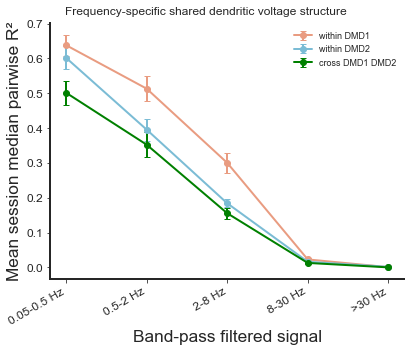

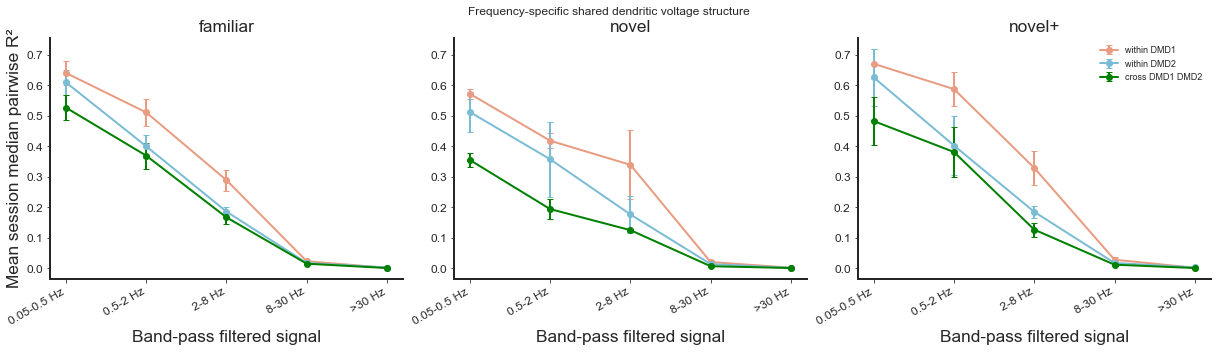

In [157]:

def plot_frequency_across_sessions(freq_session_band_df, metric="median_r2", facet_by=None):
    """Across-session summary of band-limited shared structure."""
    if freq_session_band_df.empty:
        raise ValueError("freq_session_band_df is empty. Run the frequency sweep first.")

    df = freq_session_band_df.copy()
    band_order = df[["band_order", "band_label"]].drop_duplicates().sort_values("band_order")
    labels = band_order["band_label"].tolist()
    x = np.arange(len(labels))

    group_order = _ordered_pair_groups(df)

    if facet_by is not None and facet_by in df.columns:
        categories = [c for c in ["familiar", "novel", "novel+"] if c in set(df[facet_by])]
        categories += [c for c in sorted(df[facet_by].dropna().unique()) if c not in categories]
    else:
        df["all"] = "all"
        facet_by = "all"
        categories = ["all"]

    fig, axes = plt.subplots(
        1,
        len(categories),
        figsize=(5.6 * len(categories), 4.6),
        sharey=True,
        constrained_layout=True,
    )

    if len(categories) == 1:
        axes = [axes]

    for ax, cat in zip(axes, categories):
        ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
        ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
        for spine in ['left','bottom']:
            ax.spines[spine].set_linewidth(2)
        sub = df[df[facet_by] == cat]
        for i,group in enumerate(group_order):
            gdf = sub[sub["pair_group"] == group]
            if gdf.empty:
                continue
            stats = (
                gdf.groupby(["band_order", "band_label"])
                .agg(mean=(metric, "mean"), sem=(metric, _sem), n=(metric, "count"))
                .reset_index()
                .sort_values("band_order")
            )
            ax.errorbar(
                stats["band_order"],
                stats["mean"],
                yerr=stats["sem"],
                marker="o",
                lw=2,
                capsize=3,
                label=group.replace("_", " "),color=DMD_COLORS[i]
            )

        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=30, ha="right")
        ax.set_xlabel("Band-pass filtered signal")
        if facet_by != "all":
            ax.set_title(str(cat))
        ax.spines[["top", "right"]].set_visible(False)

    ylabel = {
        "median_r2": "Mean session median pairwise R²",
        "median_abs_r": "Mean session median |r|",
        "median_r": "Mean session median r",
        "mean_r2": "Mean session mean pairwise R²",
        "q90_r2": "Mean session 90th percentile R²",
    }.get(metric, metric)
    axes[0].set_ylabel(ylabel)
    axes[-1].legend(frameon=False, fontsize=9, loc="best")
    fig.suptitle("Frequency-specific shared dendritic voltage structure", y=1.03)
    return fig, axes


fig, axes = plot_frequency_across_sessions(freq_session_band_df, metric=FREQ_SUMMARY_METRIC, facet_by=None)


file_base = FREQ_OUT_DIR / f"{today_str}_across_session_bandlimited_{FREQ_SUMMARY_METRIC}"
save_figure(fig, str(file_base), formats=[".pdf", ".png"], dpi=300)
plt.show()

# Optional session-type faceting. This is useful for exploration, but interpret cautiously if session counts are imbalanced.
if not freq_session_band_df.empty and "session_category" in freq_session_band_df.columns:
    fig, axes = plot_frequency_across_sessions(freq_session_band_df, metric=FREQ_SUMMARY_METRIC, facet_by="session_category")
    file_base = FREQ_OUT_DIR / f"{today_str}_across_session_bandlimited_{FREQ_SUMMARY_METRIC}_sessiontype"
    save_figure(fig, str(file_base), formats=[".pdf", ".png"], dpi=300)
    plt.show()


In [110]:

# Save frequency-domain tables for follow-up analysis and slide building.
freq_pair_csv = FREQ_OUT_DIR / f"{today_str}_frequency_pairwise_roi_correlations_all_pairs.csv"
freq_window_csv = FREQ_OUT_DIR / f"{today_str}_frequency_pairwise_roi_correlations_window_summary.csv"
freq_session_csv = FREQ_OUT_DIR / f"{today_str}_frequency_pairwise_roi_correlations_session_band_summary.csv"
freq_log_csv = FREQ_OUT_DIR / f"{today_str}_frequency_pairwise_roi_correlations_sweep_log.csv"

if not freq_pair_df_all.empty:
    freq_pair_df_all.to_csv(freq_pair_csv, index=False)
if not freq_window_summary_df.empty:
    freq_window_summary_df.to_csv(freq_window_csv, index=False)
if not freq_session_band_df.empty:
    freq_session_band_df.to_csv(freq_session_csv, index=False)
if not freq_sweep_log_df.empty:
    freq_sweep_log_df.to_csv(freq_log_csv, index=False)

print("Saved frequency-domain outputs:")
print(freq_pair_csv)
print(freq_window_csv)
print(freq_session_csv)
print(freq_log_csv)


Saved frequency-domain outputs:
C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\asap7_signal_correlations\frequency_shared_structure\2026-07-08_frequency_pairwise_roi_correlations_all_pairs.csv
C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\asap7_signal_correlations\frequency_shared_structure\2026-07-08_frequency_pairwise_roi_correlations_window_summary.csv
C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\asap7_signal_correlations\frequency_shared_structure\2026-07-08_frequency_pairwise_roi_correlations_session_band_summary.csv
C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\asap7_signal_correlations\frequency_shared_structure\2026-07-08_frequency_pairwise_roi_correlation

In [144]:
# %%
# PSD analysis configuration.

PSD_OUT_DIR = OUT_DIR / "psd_across_sessions"
PSD_OUT_DIR.mkdir(parents=True, exist_ok=True)

PSD_SIGNAL = SIGNAL

# Keep this high enough for 120/200 Hz structure.
PSD_TARGET_FS_HZ = 2500.0

# Windowing strategy.
# For lower-frequency resolution, increase PSD_WINDOW_SEC and PSD_WELCH_NPERSEG_SEC.
# 180 s is fast and safe; 600 s gives better low-frequency resolution.
PSD_WINDOW_SEC = 600.0
PSD_N_WINDOWS_PER_SESSION = 4
PSD_WINDOW_START_MODE = "even"
PSD_MAX_SESSIONS = None

# Welch parameters.
PSD_WELCH_NPERSEG_SEC = 120.0
PSD_WELCH_OVERLAP_FRAC = 0.5

# Plot / interpolation grid.
PSD_PLOT_FMIN = 0.001
PSD_PLOT_FMAX = 1000.0
PSD_N_FREQ_GRID = 700
PSD_EPS = 1e-20

# "raw" preserves absolute dF/F0 power.
# "zscore" compares spectral shape independent of ROI/session amplitude.
PSD_INPUT_MODE = "zscore"   # "raw", "demean", or "zscore"

# Optional artifact clipping before PSD.
PSD_ROBUST_CLIP_Z = ROBUST_CLIP_Z

PSD_COMMON_FREQS = np.logspace(
    np.log10(PSD_PLOT_FMIN),
    np.log10(PSD_PLOT_FMAX),
    PSD_N_FREQ_GRID,
)

SPECIAL_FREQS = {
    "image cadence": 1 / 0.75,
    "60 Hz": 60.0,
    "120 Hz": 120.0
}

PSD_DMD_COLOR_MAP = {
    "DMD1": DMD_COLORS[0] if "DMD_COLORS" in globals() else None,
    "DMD2": DMD_COLORS[1] if "DMD_COLORS" in globals() else None,
}

print("PSD output:", PSD_OUT_DIR)

PSD output: C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\asap7_signal_correlations\psd_across_sessions


In [145]:
# %%
def _psd_sem(x, axis=0):
    x = np.asarray(x, dtype=float)
    n = np.sum(np.isfinite(x), axis=axis)
    sd = np.nanstd(x, axis=axis, ddof=1)
    return sd / np.sqrt(np.maximum(n, 1))


def _psd_interp_nans_rows(X):
    X = np.asarray(X, dtype=np.float32).copy()
    n_rois, n_time = X.shape

    for i in range(n_rois):
        x = X[i]
        finite = np.isfinite(x)
        if finite.all():
            continue
        if finite.sum() == 0:
            X[i] = 0
        elif finite.sum() == 1:
            X[i] = x[finite][0]
        else:
            idx = np.arange(n_time)
            X[i, ~finite] = np.interp(idx[~finite], idx[finite], x[finite])

    return X


def _psd_robust_clip_rows(X, z=None):
    if z is None:
        return X

    X = np.asarray(X, dtype=np.float32)

    med = np.nanmedian(X, axis=1, keepdims=True)
    mad = np.nanmedian(np.abs(X - med), axis=1, keepdims=True)
    scale = 1.4826 * mad

    sd = np.nanstd(X, axis=1, keepdims=True)
    bad = (~np.isfinite(scale)) | (scale <= 0)

    scale = np.where(bad, sd, scale)
    scale = np.where((~np.isfinite(scale)) | (scale <= 0), 1.0, scale)

    return np.clip(X, med - z * scale, med + z * scale)


def _psd_prepare_input(X, mode="raw"):
    X = np.asarray(X, dtype=np.float32)
    X = _psd_interp_nans_rows(X)

    if mode == "raw":
        return X

    if mode == "demean":
        return X - np.nanmean(X, axis=1, keepdims=True)

    if mode == "zscore":
        X0 = X - np.nanmean(X, axis=1, keepdims=True)
        sd = np.nanstd(X0, axis=1, keepdims=True)
        sd[~np.isfinite(sd) | (sd <= 0)] = 1.0
        return X0 / sd

    raise ValueError(f"Unknown PSD_INPUT_MODE: {mode!r}")


def _psd_estimate_fs(t):
    t = np.asarray(t, dtype=float)
    dt = np.nanmedian(np.diff(t))
    if not np.isfinite(dt) or dt <= 0:
        return np.nan
    return float(1.0 / dt)


def _psd_infer_trace_layout(y_ds, t_ds):
    n_time = len(t_ds)
    shape = tuple(y_ds.shape)

    if len(shape) != 2:
        raise ValueError(f"Expected 2D trace dataset; got shape {shape}")

    if shape[1] == n_time:
        return "roi_time", shape[0], shape[1]

    if shape[0] == n_time:
        return "time_roi", shape[1], shape[0]

    raise ValueError(f"Could not infer trace layout. Trace shape={shape}; time length={n_time}")


def _psd_decode_roi_ids(x, n=None):
    if x is None:
        return np.asarray([str(i) for i in range(n or 0)], dtype=str)

    out = []
    for v in x:
        if isinstance(v, bytes):
            out.append(v.decode("utf-8"))
        else:
            out.append(str(v))

    return np.asarray(out, dtype=str)


def _psd_group_keys(h5):
    return sorted([k for k in h5.keys() if k.upper().startswith("DMD")])


def _time_indices_from_regular_timebase(t_ds, start_sec, stop_sec):
    """Estimate slice indices without loading the full timebase into memory."""
    n_time = len(t_ds)

    t_first = float(t_ds[0])
    t_last = float(t_ds[-1])

    n_probe = int(min(n_time, 20000))
    t_probe = np.asarray(t_ds[:n_probe], dtype=float)
    dt = float(np.nanmedian(np.diff(t_probe)))

    if not np.isfinite(dt) or dt <= 0:
        raise ValueError("Could not estimate sample interval from timebase.")

    i0 = int(np.floor((start_sec - t_first) / dt))
    i1 = int(np.ceil((stop_sec - t_first) / dt))

    i0 = max(0, min(i0, n_time - 1))
    i1 = max(i0 + 2, min(i1, n_time))

    return i0, i1, dt, t_first, t_last


def load_voltage_window_for_psd(
    trace_h5,
    *,
    signal="dff",
    start_sec,
    window_sec,
    target_fs_hz=500.0,
    valid_rois_only=True,
    robust_clip_z=None,
):
    """
    Load a decimated window for PSD calculation.

    This reads the H5 trace with a stride, rather than loading the full
    native 10.8 kHz window and downsampling afterward.
    """
    out = {
        "trace_h5": str(trace_h5),
        "signal": signal,
        "start_sec": float(start_sec),
        "window_sec": float(window_sec),
        "target_fs_hz": float(target_fs_hz),
        "dmd": {},
    }

    with h5py.File(trace_h5, "r") as h5:
        dmd_keys = _psd_group_keys(h5)

        for dmd in dmd_keys:
            g = h5[dmd]
            if signal not in g or "timebase_sec" not in g:
                continue

            y_ds = g[signal]
            t_ds = g["timebase_sec"]

            layout, n_rois, n_time = _psd_infer_trace_layout(y_ds, t_ds)

            i0, i1, raw_dt, _, _ = _time_indices_from_regular_timebase(
                t_ds,
                start_sec,
                start_sec + window_sec,
            )

            raw_fs = 1.0 / raw_dt
            stride = max(1, int(round(raw_fs / target_fs_hz)))

            t = np.asarray(t_ds[i0:i1:stride], dtype=np.float64)

            if layout == "roi_time":
                X = np.asarray(y_ds[:, i0:i1:stride], dtype=np.float32)
            else:
                X = np.asarray(y_ds[i0:i1:stride, :], dtype=np.float32).T

            roi_ids = _psd_decode_roi_ids(g["roi_ids"][:] if "roi_ids" in g else None, n=n_rois)
            source_roi_indices = np.arange(n_rois, dtype=int)

            if valid_rois_only and "valid_rois_mask" in g:
                valid = np.asarray(g["valid_rois_mask"][:], dtype=bool)
                if len(valid) == X.shape[0]:
                    X = X[valid]
                    roi_ids = roi_ids[valid]
                    source_roi_indices = source_roi_indices[valid]

            X = _psd_interp_nans_rows(X)
            X = _psd_robust_clip_rows(X, z=robust_clip_z)

            out["dmd"][dmd] = {
                "X": X,
                "time_sec": t,
                "fs_hz": _psd_estimate_fs(t),
                "roi_ids": roi_ids,
                "source_roi_indices": source_roi_indices,
                "layout": layout,
                "stride": stride,
            }

    return out

In [146]:
# %%
def compute_window_psd(
    w,
    *,
    input_mode="raw",
    nperseg_sec=120.0,
    overlap_frac=0.5,
):
    """Compute Welch PSD for each ROI in each DMD for one loaded window."""
    psd = {
        "trace_h5": w["trace_h5"],
        "signal": w["signal"],
        "input_mode": input_mode,
        "start_sec": w["start_sec"],
        "window_sec": w["window_sec"],
        "dmd": {},
    }

    for dmd, d in w["dmd"].items():
        X = _psd_prepare_input(d["X"], mode=input_mode)
        fs = float(d["fs_hz"])

        if not np.isfinite(fs) or fs <= 0:
            continue

        n_time = X.shape[1]
        nperseg = int(round(nperseg_sec * fs))
        nperseg = max(16, min(nperseg, n_time))

        noverlap = int(round(overlap_frac * nperseg))
        noverlap = max(0, min(noverlap, nperseg - 1))

        f, Pxx = scipy_signal.welch(
            X,
            fs=fs,
            window="hann",
            nperseg=nperseg,
            noverlap=noverlap,
            detrend="constant",
            scaling="density",
            axis=1,
        )

        psd["dmd"][dmd] = {
            "f": f,
            "Pxx": Pxx,
            "roi_ids": d["roi_ids"],
            "source_roi_indices": d["source_roi_indices"],
            "fs_hz": fs,
            "nperseg": nperseg,
            "noverlap": noverlap,
        }

    return psd


def _interp_log_psd_to_grid(f, Pxx, freq_grid):
    """Interpolate log10 PSD for each ROI onto a common log-frequency grid."""
    f = np.asarray(f, dtype=float)
    Pxx = np.asarray(Pxx, dtype=float)

    valid_f = np.isfinite(f) & (f > 0)
    f = f[valid_f]
    Pxx = Pxx[:, valid_f]

    logf = np.log10(f)
    log_grid = np.log10(freq_grid)

    out = np.full((Pxx.shape[0], len(freq_grid)), np.nan, dtype=np.float32)

    for i in range(Pxx.shape[0]):
        y = np.log10(Pxx[i] + PSD_EPS)
        valid = np.isfinite(y) & np.isfinite(logf)

        if valid.sum() >= 2:
            out[i] = np.interp(
                log_grid,
                logf[valid],
                y[valid],
                left=np.nan,
                right=np.nan,
            )

    return out

In [147]:
# %%
def run_across_session_psd(
    assets,
    process_df,
    *,
    signal="dff",
    target_fs_hz=500.0,
    window_sec=180.0,
    n_windows_per_session=4,
    start_mode="even",
    max_sessions=None,
    input_mode="raw",
    nperseg_sec=120.0,
    overlap_frac=0.5,
    freq_grid=None,
    valid_rois_only=True,
    robust_clip_z=None,
    random_seed=0,
):
    if freq_grid is None:
        freq_grid = PSD_COMMON_FREQS

    rng = np.random.default_rng(random_seed)

    session_rows = []
    window_rows = []
    roi_rows = []
    log_rows = []

    session_indices = list(range(len(assets)))
    if max_sessions is not None:
        session_indices = session_indices[:int(max_sessions)]

    for si in session_indices:
        asset = assets[si]
        row = process_df.iloc[si]
        meta = session_metadata_from_row(row, session_index=si)

        try:
            trace_h5 = resolve_voltage_h5(asset)
            t0, t1 = _common_time_range_for_signal(trace_h5, signal=signal)

            if t0 is None:
                raise KeyError(f"Signal {signal!r} not found in H5.")

            starts = choose_window_starts(
                t0,
                t1,
                window_sec,
                n_windows=n_windows_per_session,
                start_pad_sec=START_PAD_SEC,
                mode=start_mode,
                rng=rng,
            )

            if len(starts) == 0:
                raise ValueError("No valid PSD windows found.")

            per_session = {}

            for wi, start_sec in enumerate(starts):
                w = load_voltage_window_for_psd(
                    trace_h5,
                    signal=signal,
                    start_sec=start_sec,
                    window_sec=window_sec,
                    target_fs_hz=target_fs_hz,
                    valid_rois_only=valid_rois_only,
                    robust_clip_z=robust_clip_z,
                )

                psd = compute_window_psd(
                    w,
                    input_mode=input_mode,
                    nperseg_sec=nperseg_sec,
                    overlap_frac=overlap_frac,
                )

                for dmd, d in psd["dmd"].items():
                    logP_roi = _interp_log_psd_to_grid(d["f"], d["Pxx"], freq_grid)

                    if logP_roi.size == 0:
                        continue

                    mean_logP_window = np.nanmean(logP_roi, axis=0)

                    for fi, freq in enumerate(freq_grid):
                        window_rows.append({
                            **meta,
                            "trace_h5": str(trace_h5),
                            "dmd": dmd,
                            "window_index": wi,
                            "window_start_sec": float(start_sec),
                            "window_sec": float(window_sec),
                            "freq_hz": float(freq),
                            "mean_log10_psd": float(mean_logP_window[fi]),
                            "mean_psd": float(10 ** mean_logP_window[fi]),
                            "n_rois": int(logP_roi.shape[0]),
                            "input_mode": input_mode,
                            "target_fs_hz": target_fs_hz,
                            "welch_nperseg_sec": nperseg_sec,
                        })

                    # Optional ROI-level output, useful for later QC but still moderate in size.
                    for ri, roi_id in enumerate(d["roi_ids"]):
                        for fi, freq in enumerate(freq_grid):
                            roi_rows.append({
                                **meta,
                                "dmd": dmd,
                                "window_index": wi,
                                "window_start_sec": float(start_sec),
                                "window_sec": float(window_sec),
                                "roi_id": str(roi_id),
                                "source_roi_index": int(d["source_roi_indices"][ri]),
                                "freq_hz": float(freq),
                                "log10_psd": float(logP_roi[ri, fi]),
                                "psd": float(10 ** logP_roi[ri, fi]),
                                "input_mode": input_mode,
                            })

                    per_session.setdefault(dmd, []).append(logP_roi)

            # Session-level average: average over all ROIs and windows within session.
            for dmd, logP_list in per_session.items():
                logP_stack = np.concatenate(logP_list, axis=0)

                mean_logP_session = np.nanmean(logP_stack, axis=0)
                sem_logP_session = _psd_sem(logP_stack, axis=0)

                for fi, freq in enumerate(freq_grid):
                    session_rows.append({
                        **meta,
                        "trace_h5": str(trace_h5),
                        "dmd": dmd,
                        "freq_hz": float(freq),
                        "mean_log10_psd": float(mean_logP_session[fi]),
                        "sem_log10_psd_within_session": float(sem_logP_session[fi]),
                        "mean_psd": float(10 ** mean_logP_session[fi]),
                        "n_roi_windows": int(logP_stack.shape[0]),
                        "n_windows": int(len(starts)),
                        "window_sec": float(window_sec),
                        "input_mode": input_mode,
                        "target_fs_hz": target_fs_hz,
                        "welch_nperseg_sec": nperseg_sec,
                    })

            log_rows.append({**meta, "status": "ok", "n_windows": len(starts), "trace_h5": str(trace_h5)})

        except Exception as exc:
            log_rows.append({**meta, "status": "error", "error": repr(exc)})

    session_psd_df = pd.DataFrame(session_rows)
    window_psd_df = pd.DataFrame(window_rows)
    roi_psd_df = pd.DataFrame(roi_rows)
    psd_log_df = pd.DataFrame(log_rows)

    return session_psd_df, window_psd_df, roi_psd_df, psd_log_df

In [148]:
# %%
session_psd_df, window_psd_df, roi_psd_df, psd_log_df = run_across_session_psd(
    assets,
    process_df,
    signal=PSD_SIGNAL,
    target_fs_hz=PSD_TARGET_FS_HZ,
    window_sec=PSD_WINDOW_SEC,
    n_windows_per_session=PSD_N_WINDOWS_PER_SESSION,
    start_mode=PSD_WINDOW_START_MODE,
    max_sessions=PSD_MAX_SESSIONS,
    input_mode=PSD_INPUT_MODE,
    nperseg_sec=PSD_WELCH_NPERSEG_SEC,
    overlap_frac=PSD_WELCH_OVERLAP_FRAC,
    freq_grid=PSD_COMMON_FREQS,
    valid_rois_only=VALID_ROIS_ONLY,
    robust_clip_z=PSD_ROBUST_CLIP_Z,
    random_seed=RANDOM_SEED,
)

display(psd_log_df)
display(session_psd_df.head())

psd_session_csv = PSD_OUT_DIR / f"{today_str}_across_session_psd_session_summary_{PSD_INPUT_MODE}.csv"
psd_window_csv = PSD_OUT_DIR / f"{today_str}_across_session_psd_window_summary_{PSD_INPUT_MODE}.csv"
psd_roi_csv = PSD_OUT_DIR / f"{today_str}_across_session_psd_roi_level_{PSD_INPUT_MODE}.csv"
psd_log_csv = PSD_OUT_DIR / f"{today_str}_across_session_psd_log_{PSD_INPUT_MODE}.csv"

session_psd_df.to_csv(psd_session_csv, index=False)
window_psd_df.to_csv(psd_window_csv, index=False)
roi_psd_df.to_csv(psd_roi_csv, index=False)
psd_log_df.to_csv(psd_log_csv, index=False)

print("Saved:")
print(psd_session_csv)
print(psd_window_csv)
print(psd_roi_csv)
print(psd_log_csv)

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_7756\3050677408.py:85: RuntimeWarning: Mean of empty slice
  mean_logP_window = np.nanmean(logP_roi, axis=0)
C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_7756\3050677408.py:127: RuntimeWarning: Mean of empty slice
  mean_logP_session = np.nanmean(logP_stack, axis=0)
C:\Users\andrew.shelton\Anaconda3\lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


,session_index,subject_id,session_id,session_date,session_category,status,n_windows,trace_h5
0,0,826031,826031_2026-01-30_15-04-02,2026-01-30,familiar,ok,4,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
1,1,826031,826031_2026-02-01_11-01-50,2026-02-01,familiar,ok,4,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
2,2,826031,826031_2026-02-02_10-23-53,2026-02-02,familiar,ok,4,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
3,3,826031,826031_2026-02-03_14-21-45,2026-02-03,familiar,ok,4,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
4,4,826031,826031_2026-02-04_12-15-34,2026-02-04,familiar,ok,4,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
5,5,826031,826031_2026-02-05_09-28-56,2026-02-05,familiar,ok,4,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
6,6,826031,826031_2026-02-06_10-21-20,2026-02-06,familiar,ok,4,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
7,7,826031,826031_2026-02-10_10-48-51,2026-02-10,novel,ok,4,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
8,8,826031,826031_2026-02-11_12-42-21,2026-02-11,novel+,ok,4,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
9,9,826031,826031_2026-02-12_07-43-37,2026-02-12,novel+,ok,4,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...


,session_index,subject_id,session_id,session_date,session_category,trace_h5,dmd,freq_hz,mean_log10_psd,sem_log10_psd_within_session,mean_psd,n_roi_windows,n_windows,window_sec,input_mode,target_fs_hz,welch_nperseg_sec
0,0,826031,826031_2026-01-30_15-04-02,2026-01-30,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,DMD1,0.001000,NaN,NaN,NaN,48,4,600.0,zscore,2500.0,120.0
1,0,826031,826031_2026-01-30_15-04-02,2026-01-30,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,DMD1,0.001020,NaN,NaN,NaN,48,4,600.0,zscore,2500.0,120.0
2,0,826031,826031_2026-01-30_15-04-02,2026-01-30,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,DMD1,0.001040,NaN,NaN,NaN,48,4,600.0,zscore,2500.0,120.0
3,0,826031,826031_2026-01-30_15-04-02,2026-01-30,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,DMD1,0.001061,NaN,NaN,NaN,48,4,600.0,zscore,2500.0,120.0
4,0,826031,826031_2026-01-30_15-04-02,2026-01-30,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,DMD1,0.001082,NaN,NaN,NaN,48,4,600.0,zscore,2500.0,120.0


Saved:
C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\asap7_signal_correlations\psd_across_sessions\2026-07-08_across_session_psd_session_summary_zscore.csv
C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\asap7_signal_correlations\psd_across_sessions\2026-07-08_across_session_psd_window_summary_zscore.csv
C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\asap7_signal_correlations\psd_across_sessions\2026-07-08_across_session_psd_roi_level_zscore.csv
C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\asap7_signal_correlations\psd_across_sessions\2026-07-08_across_session_psd_log_zscore.csv


C:\Users\andrew.shelton\Anaconda3\lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\andrew.shelton\Anaconda3\lib\site-packages\numpy\lib\nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


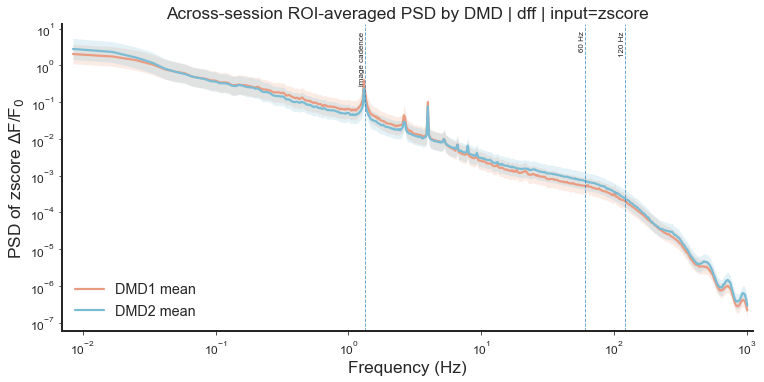

In [169]:
# %%
def _add_special_frequency_lines(ax, fmin, fmax, include_harmonics=True):
    for name, freq in SPECIAL_FREQS.items():
        if fmin <= freq <= fmax:
            ax.axvline(freq, linestyle="--", linewidth=0.9, alpha=0.7)
            ax.text(
                freq,
                0.98,
                name,
                transform=ax.get_xaxis_transform(),
                rotation=90,
                va="top",
                ha="right",
                fontsize=8,
            )

    if include_harmonics:
        image_freq = SPECIAL_FREQS["image cadence"]
        harmonics = image_freq * np.arange(2, 80)

        for freq in harmonics:
            if fmin <= freq <= fmax:
                ax.axvline(freq, linestyle=":", linewidth=0.6, alpha=0.25)


def _add_band_spans(ax, bands, fmin, fmax):
    for band, bounds in bands.items():
        lo, hi = bounds
        lo2 = max(float(lo), fmin)
        hi2 = min(float(hi), fmax)

        if hi2 > lo2:
            ax.axvspan(lo2, hi2, alpha=0.035)


def plot_across_session_dmd_mean_psd(
    session_psd_df,
    *,
    fmin=0.001,
    fmax=1000.0,
    show_bands=True,
    include_harmonics=True,
    show_individual_sessions=True,
):
    df = session_psd_df.copy()

    if df.empty:
        raise ValueError("session_psd_df is empty. Run the PSD sweep first.")

    df = df[(df["freq_hz"] >= fmin) & (df["freq_hz"] <= fmax)].copy()

    dmd_order = [d for d in ["DMD1", "DMD2"] if d in set(df["dmd"])]
    dmd_order += [d for d in sorted(df["dmd"].unique()) if d not in dmd_order]

    fig, ax = plt.subplots(figsize=(10.5, 5.2), constrained_layout=True)

    if show_bands and "FREQ_BANDS" in globals():
        _add_band_spans(ax, FREQ_BANDS, fmin=fmin, fmax=fmax)

    for dmd in dmd_order:
        sub = df[df["dmd"] == dmd].copy()

        if sub.empty:
            continue

        color = PSD_DMD_COLOR_MAP.get(dmd, None)

        if show_individual_sessions:
            for _, sdf in sub.groupby("session_index"):
                sdf = sdf.sort_values("freq_hz")
                ax.plot(
                    sdf["freq_hz"],
                    sdf["mean_psd"],
                    color=color,
                    alpha=0.16,
                    linewidth=0.8,
                )

        stats = (
            sub
            .groupby("freq_hz", as_index=False)
            .agg(
                mean_log10_psd=("mean_log10_psd", "mean"),
                sem_log10_psd=("mean_log10_psd", _psd_sem),
                n_sessions=("session_index", "nunique"),
            )
            .sort_values("freq_hz")
        )

        f = stats["freq_hz"].to_numpy()
        mu = stats["mean_log10_psd"].to_numpy()
        se = stats["sem_log10_psd"].to_numpy()

        ax.plot(
            f,
            10 ** mu,
            linewidth=2.2,
            label=f"{dmd} mean",
            color=color,
        )

        ax.fill_between(
            f,
            10 ** (mu - se),
            10 ** (mu + se),
            alpha=0.20,
            linewidth=0,
            color=color,
        )

    _add_special_frequency_lines(
        ax,
        fmin=fmin,
        fmax=fmax,
        include_harmonics=include_harmonics,
    )

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(fmin, fmax)

    ax.set_xlabel("Frequency (Hz)")

    if PSD_INPUT_MODE == "raw":
        ax.set_ylabel("PSD of ΔF/F$_{0}$")
    else:
        ax.set_ylabel(f"PSD of {PSD_INPUT_MODE} ΔF/F$_{0}$")

    ax.set_title(
        f"Across-session ROI-averaged PSD by DMD | {PSD_SIGNAL} | input={PSD_INPUT_MODE}"
    )

    ax.legend(frameon=False,loc='lower left')
    ax.spines[["top", "right"]].set_visible(False)

    return fig, ax


fig, ax = plot_across_session_dmd_mean_psd(
    session_psd_df,
    fmin=0.001,
    fmax=1000,
    show_bands=False,
    include_harmonics=False,
    show_individual_sessions=False,
)

# ax.set_ylim(1e-6,1)
ax.set_xlim(1e-3+0.006,1e3+100)
ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)

file_base = PSD_OUT_DIR / f"{today_str}_across_session_dmd_mean_psd_{PSD_INPUT_MODE}"
save_figure(fig, str(file_base), formats=[".pdf", ".png"], dpi=300)
plt.show()